# Chicago Crime

**Author:** Erik Pak 
**Date:** 04/2026 
**Data:** Chicago Data Portal - Crime Incidents 2001-2025


https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data

https://data.cityofchicago.org/Public-Safety/Chicago-Police-Department-Illinois-Uniform-Crime-R/c7ck-438e/about_data

___
## Scope:
We are modeling crime incidence as a multivariate, non-stationary stochastic process and detecting shifts in crime types via structural break detection in latent distributional parameters across the pre-COVID, COVID, and post-COVID periods. How crime structures differ across eras, and which crimes move together in each era.

## Era Definitions

| Era    | Period         | Months |
|------------|-------------------------|--------|
| Pre-COVID | Jan 2001 - Feb 2020   | 230  |
| COVID   | Mar 2020 - Dec 2022   | 34   |
| Post-COVID | Jan 2023 - April 2026   | 40   |

Era cutoff rationale: The COVID era begins in March 2020, coinciding with the Illinois stay-at-home order (March 21, 2020) and the WHO pandemic declaration (March 11, 2020). The post-COVID era begins in January 2023, following the expiration of Illinois's disaster proclamation and the effective end of major federal pandemic-era policies in late 2022. These boundaries are administrative and policy-based; the underlying behavioral and enforcement shifts may not align exactly with these dates.

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn.preprocessing import StandardScaler
import ruptures as rpt

# Path + custom modules---
sys.path.append('../Src/') 
import clr_config as cfg
import clr_utilities as utils
import clr_eps_grid as grid
import clr_analyze_plot as plot
import clr_era as clr
import clr_pca_sign_normalization as pca_anchor

# Image Path
image_path = "../Image/"

# Seed
_RANDOM_STATE = 1776

# Library versions
versions = {
  "Python" : sys.version.split()[0],
  "Pandas" : pd.__version__,
  "NumPy"  : np.__version__,
  "Pyarrow" : pa.__version__,
  "Seaborn" : sns.__version__,
  "Matplot" : sys.modules['matplotlib'].__version__,
  "Ruptures": sys.modules['ruptures'].__version__,
  "Scipy"  : sys.modules['scipy'].__version__,
}
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=6, linewidth=100)

    Library  Version
0    Python   3.13.9
1    Pandas    2.3.3
2     NumPy    2.3.4
3   Pyarrow   22.0.0
4   Seaborn   0.13.2
5   Matplot   3.10.7
6  Ruptures  v1.1.10
7     Scipy   1.16.3


## Data Import

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,...,y_coordinate,era,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location
8265318,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSSESS - CANNABIS 30 GRAMS OR LESS,N,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,...,1857566,pre_covid,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing
7080787,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,I,THEFT,FROM BUILDING,APARTMENT,...,1854276,pre_covid,July,Saturday,Q3,2003-Q3,Evening,Larceny - Theft,True,Gresham
6396203,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSSESS - HEROIN (WHITE),N,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,...,1903996,pre_covid,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison
5818733,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,APARTMENT,...,1916864,pre_covid,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central
5312174,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,N,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,...,1914371,pre_covid,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central


## Data Integration & Cleaning

In [3]:
# New column
df['year_month'] = df['date'].dt.strftime('%Y%m')
# Normalize era keys to consistent labels
df['era'] = (
    df['era']
    .map(cfg.era_map)
    .fillna(df['era'])
    .astype(str)                 # ensure all values are strings
    .astype('string[pyarrow]')   # Arrow conversion
)
# display
df.era.unique()

<ArrowStringArray>
['Pre-COVID', 'Post-COVID', 'COVID']
Length: 3, dtype: string

In [4]:
# get the dates of period in the dataset
start_date = pd.to_datetime(df[cfg.config_agg["_DATE_KEY"]].min(), format='%Y%m').date().strftime('%Y-%m')
end_date = pd.to_datetime(df[cfg.config_agg["_DATE_KEY"]].max(), format='%Y%m').date().strftime('%Y-%m') 
# print the date range
print(f"Dataset covers from {start_date} to {end_date}")

Dataset covers from 2001-01 to 2026-04


### Full Diagnostic 

In [5]:
# Normalize year_month to datetime (keep both versions)
df['year_month_dt'] = pd.to_datetime(df['year_month'], format='%Y%m')

# Identity check
identical = bool((df['primary_description'] == df['primary_type']).all())
print(f"primary_description == primary_type: {identical}\n")

# Distinct primary_descriptions
prim_list = sorted([str(x) for x in df['primary_description'].dropna().unique()])
print(f"Distinct primary_descriptions: {len(prim_list)}")
for c in prim_list:
    print(f"  - {c}")
print()

# Distinct FBI categories
fbi_list = sorted([str(x) for x in df['fbi_code_desc'].dropna().unique()])
print(f"Distinct fbi_code_desc: {len(fbi_list)}")
for c in fbi_list:
    print(f"  - {c}")
print()

# Era boundaries are actually encoded
era_bounds = (df.groupby('era')['year_month_dt']
              .agg(['min', 'max', 'nunique'])
              .rename(columns={'nunique': 'n_months'}))
print("Era boundaries:")
print(era_bounds.to_string())
print()

# index_code vs fbi_index_code
print("index_code vs fbi_index_code:")
print(pd.crosstab(df['index_code'], df['fbi_index_code'], dropna=False))

primary_description == primary_type: False

Distinct primary_descriptions: 32
  - ARSON
  - ASSAULT
  - BATTERY
  - BURGLARY
  - CONCEALED CARRY LICENSE VIOLATION
  - CRIMINAL DAMAGE
  - CRIMINAL SEXUAL ASSAULT
  - CRIMINAL TRESPASS
  - DECEPTIVE PRACTICE
  - GAMBLING
  - HOMICIDE
  - HUMAN TRAFFICKING
  - INTERFERENCE WITH PUBLIC OFFICER
  - INTIMIDATION
  - KIDNAPPING
  - LIQUOR LAW VIOLATION
  - MOTOR VEHICLE THEFT
  - NARCOTICS
  - NON-CRIMINAL
  - OBSCENITY
  - OFFENSE INVOLVING CHILDREN
  - OTHER NARCOTIC VIOLATION
  - OTHER OFFENSE
  - PROSTITUTION
  - PUBLIC INDECENCY
  - PUBLIC PEACE VIOLATION
  - RITUALISM
  - ROBBERY
  - SEX OFFENSE
  - STALKING
  - THEFT
  - WEAPONS VIOLATION

Distinct fbi_code_desc: 26
  - Aggravated Assault
  - Aggravated Battery
  - Arson
  - Burglary
  - Criminal Sexual Assault
  - Disorderly Conduct
  - Drug Abuse Violations
  - Embezzlement
  - Forgery and Counterfeiting
  - Fraud
  - Gambling
  - Homicide - 1st or 2nd Degree
  - Involuntary Manslaugh

### Check missingness

In [6]:
# Check integrity and missingness
missingness_results = utils.run_integrity_report(df)


--------------------------------------------------
 📑  PANEL INTEGRITY & SPARSITY DIAGNOSTIC
--------------------------------------------------
  • Date Horizon   : 2001-01 to 2026-04
  • Total Months   : 304
  • Feature Space  : 26 crime categories
  • Total Panel    : 7,904 (expected combinations)
  • Actual Density : 7,627 (observed rows)
--------------------------------------------------
  ⚠️ Completeness  : 96.50%
  🔍 Missing Gaps  : 277 rows
  👯 Duplicates    : 0 rows
--------------------------------------------------

 🔥  CRITICAL: TRUE MISSING GAPS
    (These months are entirely absent from the raw data)
    ↳ Involuntary Manslaughter / Reckless Homicide   |  233 months missing
    ↳ Gambling                                       |   28 months missing
    ↳ Embezzlement                                   |   12 months missing
    ↳ Stolen Property (Buy, Receive, Possess)        |    2 months missing
    ↳ Prostitution                                   |    2 months missing

 🧪 

####  Onset Diagnostic ('Involuntary Manslaughter / Reckless Homicide)

In [7]:
# Crime type to analyze
sus = 'Involuntary Manslaughter / Reckless Homicide'

# Build a monthly time series of counts for this crime type
s = (df[df['fbi_code_desc'] == sus]      # filter to the selected crime
     .groupby('year_month_dt')           # group by month
     .size()                             # count incidents per month
     .sort_index())                      # ensure chronological order

# Basic non-zero occurrence diagnostics
print(f"First non-zero month: {s[s > 0].index.min():%Y-%m}")  # earliest month with >0 incidents
print(f"Last non-zero month:  {s[s > 0].index.max():%Y-%m}")  # latest month with >0 incidents
print(f"Total non-zero months: {(s > 0).sum()}")              # number of months with any incidents

# Summary statistics for the monthly counts
print(f"\nMonthly count statistics:")
print(s.describe())                      # mean, std, min, quartiles, max

# Yearly aggregation: how this crime behaves year by year
yearly = pd.DataFrame({
    'months_with_data': s.groupby(s.index.year).apply(lambda x: (x > 0).sum()),  # months with > 0 incidents
    'total_count':      s.groupby(s.index.year).sum(),                           # total incidents per year
    'max_in_year':      s.groupby(s.index.year).max(),                           # worst month in each year
})

# Display the yearly pattern in a readable table
print(f"\nYearly pattern:")
print(yearly.to_string())

First non-zero month: 2002-11
Last non-zero month:  2025-09
Total non-zero months: 71

Monthly count statistics:
count    71.000000
mean      1.253521
std       0.499094
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
dtype: float64

Yearly pattern:
               months_with_data  total_count  max_in_year
year_month_dt                                            
2002                          1            1            1
2003                          3            3            1
2004                          1            1            1
2005                          1            2            2
2006                          5            6            2
2011                          1            1            1
2012                          1            1            1
2013                          1            1            1
2014                          2            2            1
2015                          5            6            2
2016   

#### Confirm

In [8]:
iucr_by_year = (df[df['fbi_code_desc'] == sus]
                .assign(yr=lambda d: d['date'].dt.year)
                .groupby(['yr', 'iucr'])
                .size()
                .reset_index(name='n'))
print(iucr_by_year.to_string(index=False))

# Also: what IUCR codes appear in this FBI category overall?
codes = df.loc[df['fbi_code_desc'] == sus, 'iucr'].value_counts()
print(f"\nIUCR codes mapped to this FBI category:")
print(codes)

  yr iucr  n
2002 0142  1
2003 0141  1
2003 0142  2
2004 0142  1
2005 0142  2
2006 0142  6
2011 0142  1
2012 0142  1
2013 0141  1
2014 0141  1
2014 0142  1
2015 0142  6
2016 0142  4
2017 0142  4
2018 0142 12
2019 0141  2
2019 0142  8
2020 0142  9
2021 0142  7
2022 0141  1
2022 0142  6
2023 0142  6
2024 0142  3
2025 0142  3

IUCR codes mapped to this FBI category:
iucr
0142    83
0141     6
Name: count, dtype: int64[pyarrow]


#### 📌 Summary
> - Involuntary Manslaughter / Reckless Homicide (IUCR codes 0141 and 0142) was excluded from the compositional analysis because the category was too sparse for reliable modeling. Across 304 months of data, it appeared in only 23.4% of months and totaled just 89 incidents overall, averaging fewer than one incident every three months (0.29 per month). Including such a low-frequency category in a high-dimensional compositional framework could introduce instability and distort the overall covariance structure. As a result, the final compositional analysis was conducted using the remaining 25 FBI crime categories, all of which showed at least 90.8% monthly coverage.

> - Although excluded from formal modeling, the category still showed an observable increase after 2017. Between 2018 and 2023, Chicago recorded an average of roughly 7 incidents per year (ranging from 6 to 12), compared with about 2 incidents per year (ranging from 1 to 4) between 2011 and 2017. While the counts remain too small for dependable statistical inference, the increase may reflect changes in prosecutorial practices related to drug-induced homicide cases or shifts in how fatal traffic incidents were classified during that period.

#### User Function(s)

In [9]:
def pca_prep_comparison(
    epsilon_sweep_result: dict,
    epsilon: float,
    epsilon_alt: float
):

    # Build comparison list
    eps_list = [epsilon, epsilon_alt]

    # Storage for results
    results_pca = {}

    # Loop over epsilons and generate plots
    for eps in eps_list:
        clr_df = epsilon_sweep_result["clr_dict"][eps]

        result = pca_anchor.compute_pca(
            clr_df,
            epsilon=eps,
            verbose=False,
        )

        results_pca[eps] = result

    return results_pca



def check_clr_health(sweep_result, target_eps=None):
    """
    Validates the numerical structure and CLR zero‑sum health for a specific epsilon.

    Args:
        sweep_result (dict): Output from sweep_epsilon_grid(...).
        target_eps (float, optional): Epsilon to inspect. Defaults to chosen_eps.

    Returns:
        dict: The full clr_dict (unchanged), or None if epsilon is missing.
    """

    # Default to auto‑chosen epsilon
    if target_eps is None:
        target_eps = sweep_result['meta']['chosen_eps']

    clr_dict = sweep_result.get('clr_dict', {})

    # Validate epsilon exists
    if target_eps not in clr_dict:
        print(f"⚠️ Warning: Epsilon {target_eps:.10f} not found in clr_dict.")
        return None

    # Extract the CLR dataframe
    target_df = clr_dict[target_eps]
    rows, cols = target_df.shape

    # Temporal range formatting
    start_dt = target_df.index[0].strftime('%Y-%m')
    end_dt   = target_df.index[-1].strftime('%Y-%m')

    # CLR zero‑sum health check
    mean_abs_sum = target_df.sum(axis=1).abs().mean()
    health_status = "🟢 OPTIMAL" if mean_abs_sum < 1e-12 else "🔴 RE‑CENTERING REQUIRED"

    # Output summary
    print(f"{' ERA STRUCTURE ':=^50}")
    print(f"Container Type    : {type(clr_dict).__name__}")
    print(f"Total Categories  : {cols}")

    print(f"\n{' TARGET EPSILON: ' + f'{target_eps:.10f}':-^50}")
    print(f"Dimensions        : {rows} months x {cols} categories")
    print(f"Temporal Range    : {start_dt} to {end_dt}")
    print(f"Primary Features  : {', '.join(target_df.columns[:3])} ...")
    print(f"Numerical Health  : {mean_abs_sum:.2e} ({health_status})")
    print(f"{'':=^50}")

    return clr_dict

In [10]:
# Remove Involuntary Manslaughter / Reckless Homicide
df_new = df[df.fbi_code_desc != sus]
# shape
print(f"Total Rows: {(df.shape[0]):,} & New Total Rows: {(df_new.shape[0]):,}")

Total Rows: 8,543,089 & New Total Rows: 8,543,000


In [11]:
# Fill missing data and report
fill_results = utils.fill_missing(df_new)


 🧩  CRIME DATA FILLING & PANEL ALIGNMENT
  • Date Range                     : 2001-01 to 2026-04
  • Total Groups                   : 25
  • Total Periods                  : 304
------------------------------------------------------------------
  📦 Final Panel Size               : 7,600 rows
  🩹 Filled Gaps                    : 44 rows
  🔢 Fill Value Used                : 0
------------------------------------------------------------------
 ✅ Audit flags: 'was_missing', 'is_zero_after_fill'



In [12]:
# Validate filled data
utils.validate_crime_data(fill_results['filled_df'], zero_rate_threshold = 0.05)


                   🛡️  CRIME DATA STRUCTURAL INTEGRITY CHECK                    
  ✅ Date Dtype                 : PASS | datetime64 required
  ✅ Global Sort                : PASS | Group-Date ordering
  ✅ Temporal Continuity        : PASS | Linear timeline
  ✅ Period Sync                : PASS | All groups have 304 months
  ✅ Value Range                : PASS | 0 negative values
  ✅ NaN Cleanup                : PASS | 0 missing entries
  ✅ Record Uniqueness          : PASS | 0 duplicates
  ✅ Audit: was_missing         : PASS | Traceability
  ✅ Audit: is_zero_after_fill  : PASS | Traceability
--------------------------------------------------------------------------------
  🔍 Overall Zero Rate          : INFO | 0.58%

 🧪  SPARSITY EXPOSURE BY CATEGORY
    (Threshold: > 5% zeros)
    ↳ Gambling                                           |    9.2% zero rate



### Centered Log-Ratio (CLR) Transformation
#### ❗ Note: Centered Log-Ratio transformation (CLR) measures the relative share of each crime category within the overall crime composition, not the raw number of crimes.
##### CLR Formula:
- $CLR(x_i) = ln(x_i + \varepsilon) - \frac{1}{K} \sum\limits_{j=1}^{K} ln(x_j + \varepsilon)$
  - $x_{i}$: The $i$-th component (or part) of the composition
  - $K$: The total number of parts (components) in the composition
  - $\frac{1}{K} \sum\limits_{j=1}^{K}ln(x_j + \varepsilon)$: This represents the arithmetic mean of the natural log of all components. This is equivalent to the logarithm of the geometric mean of the components, which is the standard reference point for the CLR
  - $\varepsilon$ (Pseudocount): A small value (often 0.5, 1, or a small constant) added to components, primarily to handle zero values in the data, as $ln(0)$ is undefined.

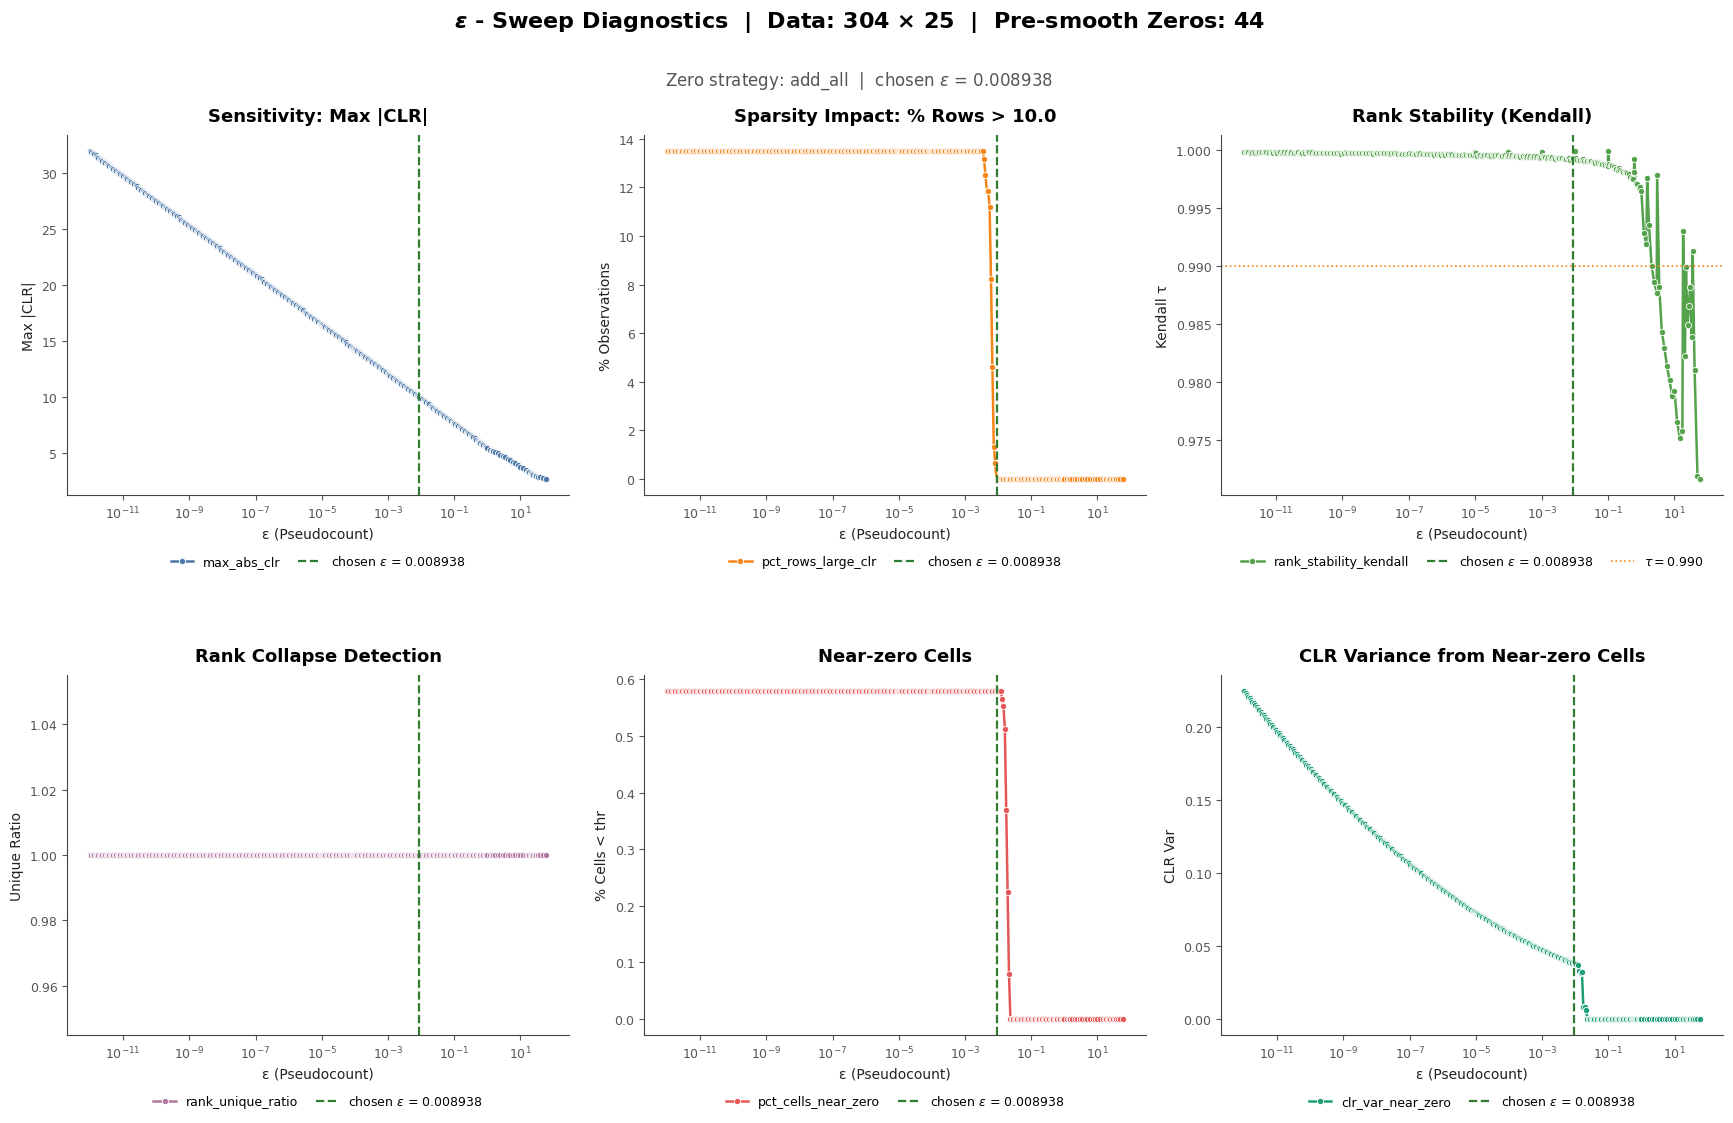

In [13]:
# Find delta constant
epsilon_result = grid.build_eps_grid(fill_results['filled_df'])
# Select Optium esp
epsilon_sweep_result = grid.sweep_epsilon_grid(epsilon_result['pivot_data'], epsilon_result['eps_values'], auto_select=True, plot=True)

In [14]:
# Extracts the transition window 
df_view, chosen_eps, prior_eps = utils.get_epsilon_transition(epsilon_sweep_result, window_prior=5, window_past=5)
df_view

index,status,is_chosen,eps,zero_strategy,max_abs_clr,mean_max_abs_clr,pct_rows_large_clr,rank_stability_spearman,rank_stability_kendall,rank_unique_ratio,rank_entropy,zero_contribution_ratio
236,❌ FALSE,,0.0055228122,add_all,10.435165,5.126980,11.184211,1.000000,0.999258,1.000000,8.247928,0.025383
237,❌ FALSE,,0.0060809597,add_all,10.342752,5.114404,8.223684,1.000000,0.999321,1.000000,8.247928,0.025283
238,❌ FALSE,,0.0066955148,add_all,10.250341,5.101813,4.605263,1.000000,0.999359,1.000000,8.247928,0.025182
239,❌ FALSE,,0.0073721781,add_all,10.157930,5.089206,1.315789,1.000000,0.999169,1.000000,8.247928,0.025080
240,❌ FALSE,,0.0081172265,add_all,10.065522,5.076581,0.657895,1.000000,0.999288,1.000000,8.247928,0.024978
241,✅ TRUE,⭐ [CHOSEN],0.0089375712,add_all,9.973115,5.063935,0.000000,1.000000,0.999344,1.000000,8.247928,0.024876
242,✅ TRUE,,0.0098408216,add_all,9.880709,5.051268,0.000000,1.000000,0.999214,1.000000,8.247928,0.024773
243,✅ TRUE,,0.0100000000,add_all,9.865308,5.049154,0.000000,1.000000,0.999906,1.000000,8.247928,0.024756
244,✅ TRUE,,0.0108353565,add_all,9.788306,5.038577,0.000000,1.000000,0.999339,1.000000,8.247928,0.024670
245,✅ TRUE,,0.0119304013,add_all,9.695904,5.025859,0.000000,1.000000,0.999126,1.000000,8.247928,0.024566


In [15]:
# PCA for CLR: Sparse
pca_result = pca_anchor.compute_pca(epsilon_sweep_result['clr_dict'][chosen_eps], epsilon=chosen_eps)


             📊 PCA DATA MANIFEST (ε = 0.00894)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0



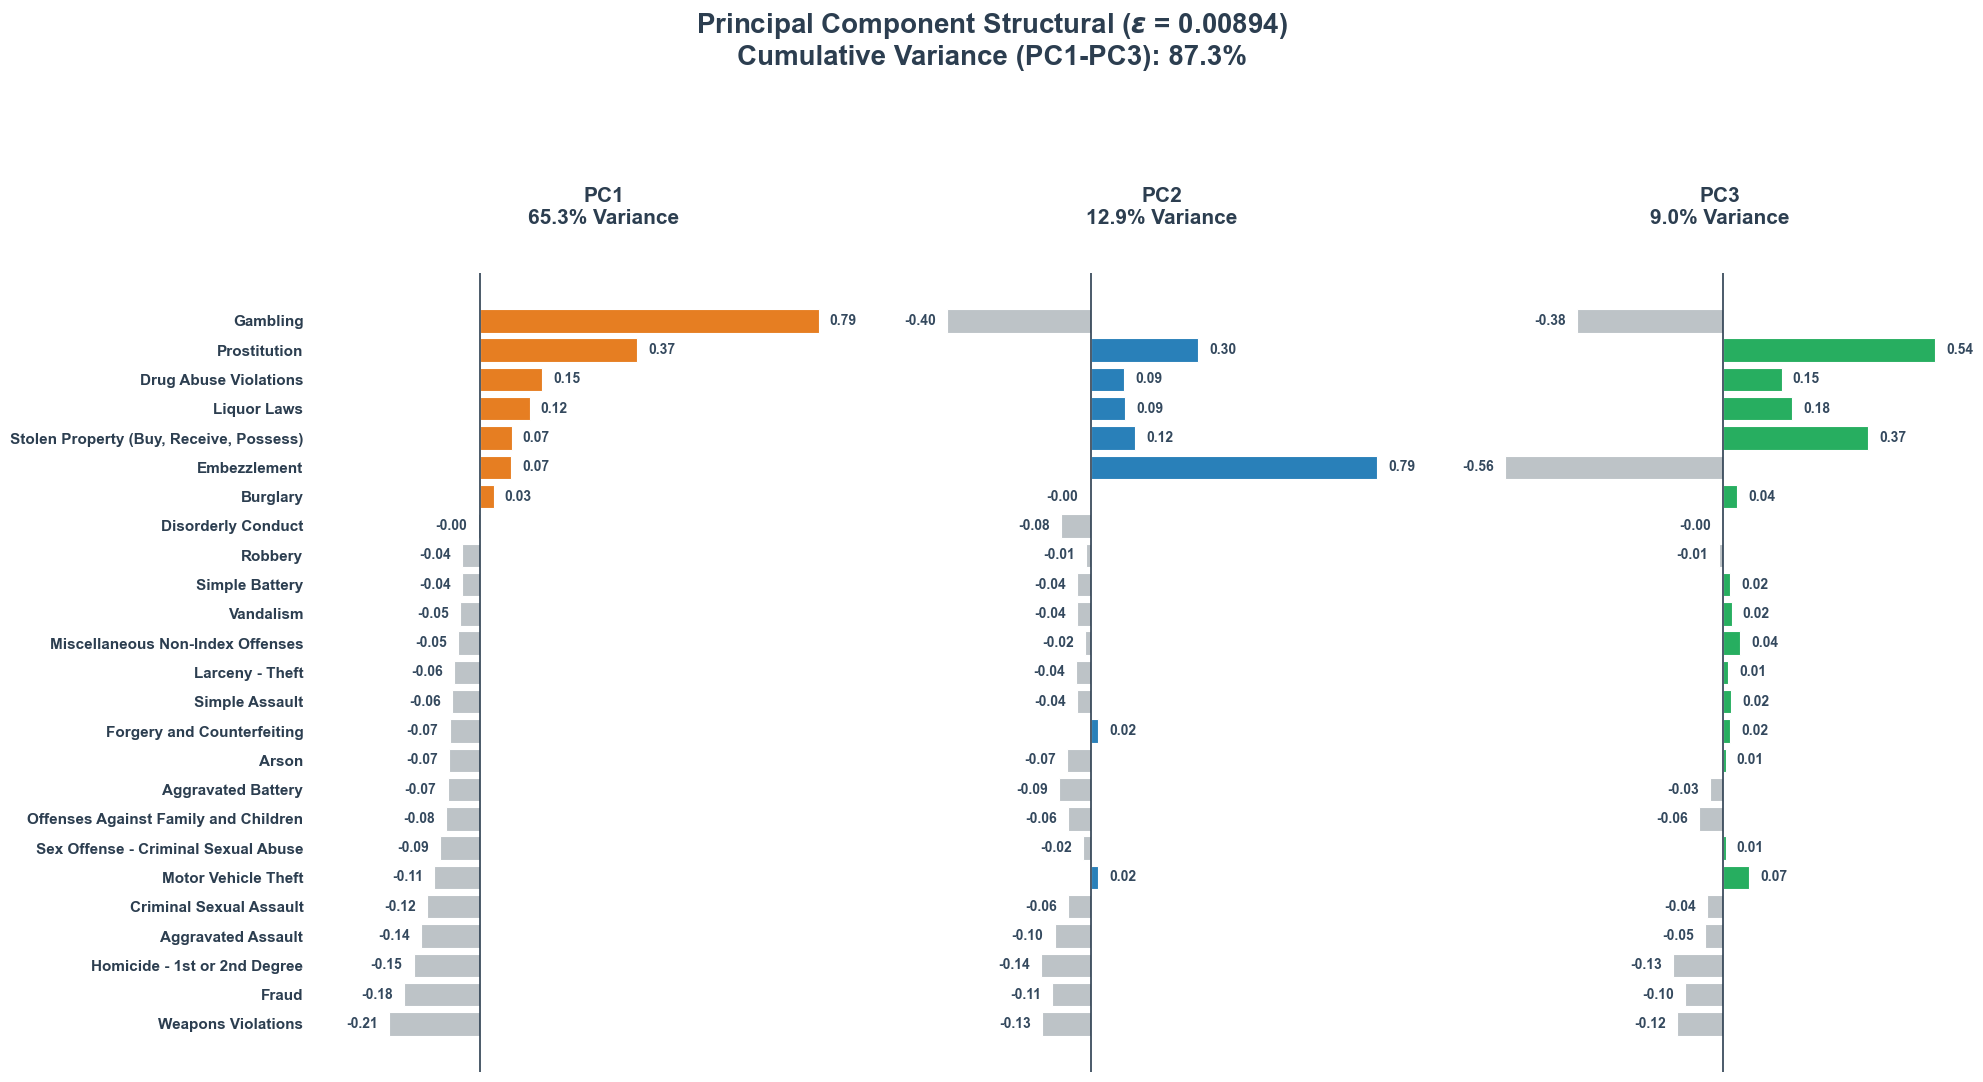

In [16]:
# Plot PCA
three_loadings_result = pca_anchor.plot_three_loadings(pca_result, epsilon=chosen_eps)

#### Gambling

In [17]:
# Copy the aggregated, filled monthly crime data
data = fill_results['filled_df']

# Extract the monthly time series for the crime category "Gambling"
gambling = (data[data['fbi_code_desc'] == 'Gambling']   # filter to Gambling incidents
            .set_index('year_month')['crime_count']     # use year_month as index, select counts
            .sort_index())                              # ensure chronological order

# Basic counts of how often Gambling appears
print(f"Total months for Gambling: {len(gambling)}")          # total months in the series
print(f"Zero months: {(gambling == 0).sum()}")                # months with zero incidents
print(f"Non-zero months: {(gambling > 0).sum()}\n")           # months with >0 incidents

# Identify all months where the gambling count is zero
gambling_zeros = gambling[gambling == 0].index

# Count zero months by calendar year
print(f"Zero months by year:")
zeros_by_year = gambling_zeros.to_series().dt.year.value_counts().sort_index()
print(zeros_by_year.to_string())

# Print every zero month in chronological order
print(f"\nAll zero months (chronologically):")
for d in gambling_zeros:
    print(f"  {d.strftime('%Y-%m')}")

# Yearly summary statistics for Gambling incidents
print(f"\nGambling yearly totals (full series):")
yearly = gambling.groupby(gambling.index.year).agg(['sum', 'mean', 'min', 'max'])
yearly.columns = ['total', 'mean_per_month', 'min', 'max']    # rename columns for clarity
print(yearly.to_string())

Total months for Gambling: 304
Zero months: 28
Non-zero months: 276

Zero months by year:
year_month
2016    1
2020    3
2021    4
2022    7
2023    4
2024    2
2025    4
2026    3

All zero months (chronologically):
  2016-12
  2020-02
  2020-04
  2020-12
  2021-01
  2021-02
  2021-08
  2021-12
  2022-01
  2022-02
  2022-04
  2022-09
  2022-10
  2022-11
  2022-12
  2023-02
  2023-04
  2023-05
  2023-11
  2024-01
  2024-02
  2025-01
  2025-02
  2025-03
  2025-12
  2026-01
  2026-02
  2026-03

Gambling yearly totals (full series):
             total  mean_per_month   min    max
year_month                                     
2001         934.0       77.833333  37.0  109.0
2002         980.0       81.666667  42.0  125.0
2003        1134.0       94.500000  41.0  139.0
2004        1194.0       99.500000  36.0  171.0
2005        1146.0       95.500000  32.0  199.0
2006        1418.0      118.166667  37.0  205.0
2007        1425.0      118.750000  22.0  214.0
2008        1205.0      100.4166

In [18]:
# Confirm the 99% claim directly
peak_window = gambling.loc['2006-01-01':'2008-12-01'].mean()
trough_window = gambling.loc['2020-01-01':'2025-12-01'].mean()
decline = 1 - (trough_window / peak_window)

print(f"Mean monthly count, 2006–2008 (peak window): {peak_window:.1f}")
print(f"Mean monthly count, 2020–2025 (trough window): {trough_window:.2f}")
print(f"Decline from peak window to trough window: {decline:.1%}")

Mean monthly count, 2006–2008 (peak window): 112.4
Mean monthly count, 2020–2025 (trough window): 1.39
Decline from peak window to trough window: 98.8%


| Period | Mean per month | Approximate decline |
|---|---:|---:|
| 2001–2008 (peak era) | 81–118 | Baseline |
| 2009–2012 | 60–83 | Modest decline |
| 2013–2015 | 26–50 | Substantial decline |
| 2016–2019 | 12–17 | Near-collapse |
| 2020 onward | 0.25–2.2 | $\approx$99% reduction from peak |


- 2009: Legislation Passed
    - July 13, 2009: Governor Pat Quinn signed the Video Gaming Act into law. It was introduced to fund a $31 billion state infrastructure improvement plan. The law authorized up to 5 VGTs in licensed retail establishments, truck stops, and veteran/fraternal organizations.
    - October 19, 2009: The Illinois Gaming Board (IGB) issued the initial emergency rules to establish the regulatory framework and licensing processes.
- 2012: VGTs Go Live
    - September 10, 2012: The Central Communications System officially launched, and the first legal VGTs went live for patron play across the state.
- 2019: Major Expansion
    - June 2019: The Illinois Gambling Expansion Bill (Public Act 101-0031) was signed into law. This legislation significantly expanded the Video Gaming Act by:
        - Increasing the maximum number of VGTs allowed in licensed truck stops from 5 to 10.
        - Increasing the maximum number of VGTs allowed in fraternal and veterans establishments from 5 to 10.
        - Raising the maximum tax rate on video gaming net terminal income.
- 2021: Post-Pandemic Adjustments.
    - October 2021: House Bill 3136 was passed, implementing further structural and regulatory updates across the state's gaming laws. This bill refined operational rules for VGTs, licenses, and revenue sharing.
- 2024–2026: Modernization and Regulatory Updates
    - 2024–2025: The IGB continued to propose and draft rule updates regarding cashless wagering, Self-Exclusion Programs, and Sales Agent Licensure to modernize oversight.
    - Ongoing: The network has grown to nearly 50,000 VGTs statewide. However, municipalities (most notably Chicago) retain the local option to prohibit video gaming terminals within their city limits.


**Note:**
> Monthly Gambling counts declined nearly monotonically over the panel, from a peak of 118.8 incidents per month in 2007 to 11.9 in 2019, then a further sharp drop to 1–2 per month from 2020 onward, a 98.8% decline between the peak window (2006-2008, mean 112.4/month) and the trough window (2020-2025, mean 1.4/month). The decline began before the July 13, 2009, enactment of the Illinois Video Gaming Act and continued through the rollout of legal Video Gaming Terminals (first patron play September 10, 2012) and the 2019 Gambling Expansion Bill. Critically, Chicago itself maintained a municipal ban on VGTs throughout the panel period (lifted only in late 2025), so the decline cannot be attributed to legal in-city substitutes for illegal gambling. Plausible contributors include geographic displacement of demand to legal suburban venues, secular de-prioritization of vice enforcement by CPD, and shifts of illegal gambling toward online platforms. Gambling remains in the compositional analysis, but post-2015 CLR values are influenced by the choice of pseudocount and should be interpreted with this in mind.

#### Prostitution

In [19]:
# Extract monthly time series for Prostitution incidents
prost = (data[data['fbi_code_desc'] == 'Prostitution']   # filter to Prostitution cases
         .set_index('year_month')['crime_count']          # use year_month as index, select counts
         .sort_index())                                   # ensure chronological order

# Yearly summary statistics for Prostitution
yearly = prost.groupby(prost.index.year).agg(['sum', 'mean', 'min', 'max'])
yearly.columns = ['total', 'mean_per_month', 'min', 'max']  # rename for clarity
print("Prostitution yearly pattern:")
print(yearly.to_string())

# Compare historical high-activity period vs recent low-activity period
peak = prost.loc['2001-01-01':'2008-12-01'].mean()          # average monthly incidents in early 2000s
trough = prost.loc['2020-01-01':'2025-12-01'].mean()        # average monthly incidents in recent years

print(f"\nPeak window mean (2001–2008): {peak:.1f}/month")
print(f"Trough window mean (2020–2025): {trough:.2f}/month")

# Compute proportional decline if peak is non-zero
if peak > 0:
    print(f"Decline: {(1 - trough/peak):.1%}")

# Identify months with zero reported Prostitution incidents
zeros = prost[prost == 0]
if len(zeros) > 0:
    print(f"\nZero months ({len(zeros)} total):")
    for d in zeros.index:
        print(f"  {d.strftime('%Y-%m')}")


Prostitution yearly pattern:
             total  mean_per_month    min    max
year_month                                      
2001        6026.0      502.166667  423.0  592.0
2002        6408.0      534.000000  437.0  612.0
2003        6214.0      517.833333  415.0  610.0
2004        7476.0      623.000000  400.0  729.0
2005        6124.0      510.333333  367.0  583.0
2006        7034.0      586.166667  404.0  712.0
2007        6087.0      507.250000  327.0  572.0
2008        5141.0      428.416667  290.0  506.0
2009        3940.0      328.333333  242.0  411.0
2010        2484.0      207.000000  172.0  278.0
2011        2424.0      202.000000  136.0  283.0
2012        2204.0      183.666667  111.0  267.0
2013        1652.0      137.666667   43.0  177.0
2014        1625.0      135.416667   69.0  197.0
2015        1322.0      110.166667   64.0  182.0
2016         800.0       66.666667   12.0  113.0
2017         735.0       61.250000   23.0   88.0
2018         718.0       59.833333   20.

**Note:**
- Phase 1: Steady street economy (2001–2008). Arrests averaged 400–630/month. This was the pre-Internet street-prostitution era, when transactions happened in person, in known geographic areas, and police could make arrests through routine patrols and stings.
- Phase 2: The internet took over (2009–2015). Arrests fell from 525/month to $\approx$110/month, roughly an 80% drop. The most likely explanation is that sex work moved online, and online platforms made street solicitation unnecessary. You don't get arrested for a transaction your buyer arranged online, and that happens behind closed doors. The activity didn't disappear, but the visible, arrestable version of it did.
- Phase 3: Legacy enforcement (2016–2019). Arrests settled into $\approx$60/month. This was a new low baseline. Most sex work was online; what remained on the street was either people who couldn't or wouldn't use online platforms, or sting operations against the people still working visibly.
- Phase 4: COVID floor (2020–2025). Arrests collapsed to $\approx$10–25/month. Lockdowns shut down what street activity remained, indoor venues closed, and post-pandemic, the numbers never returned to even the 2019 baseline.

**Legally**
- A few things, none of which is the main driver of the count decline:
    - 2010 - Illinois made minors under 18 immune from prostitution prosecution
    - 2013 - Illinois made prostitution always a misdemeanor (no more felony charges)
    - 2018 - FBI seized Backpage; federal FOSTA-SESTA passed (April 2018)

**The 96% decline in prostitution arrests in Chicago isn't a 96% decline in sex work, but it's a 96% decline in the kind of sex work that's visible to police patrols.**

#### Scaled version as a sensitivity check
Our PC1 loadings (0.79 Gambling, 0.37 Prostitution, then everything else < 0.15) reflect the fact that Gambling has enormous CLR variance; its share collapsed from $\approx$0.5% to $\approx$0.005% of monthly crime over the panel, which is a log-ratio swing of roughly log(100) $\approx$ 4.6 units. Almost no other category moved that much in CLR space. So when we fit PCA on unstandardized CLR, PC1 is essentially "the Gambling axis." That's mathematically correct and substantively defensible, but Gambling really is the category with the most extreme compositional shift. But it means PC1 isn't really a multivariate finding; instead, it's a univariate finding about Gambling, dressed up as a principal component. If you z-score the CLR coordinates first, we would be asking a different question: "What patterns of co-movement exist among the categories, treating each as equally important?" That's a legitimate question too, and the resulting PCs would tell a different story, likely one with less Gambling/Prostitution dominance and more visible signal from the high-volume violent crime categories.

#### Scale Vs. Not
| Situation | Recommendation |
|---|---|
| Following Aitchison's framework strictly | Don't scale. Use CLR + un-standardized PCA. This is the textbook choice. |
| Variance is dominated by 1-2 outlier categories | Run both, compare. We are in this situation. |
| Our downstream analysis is geometric (Aitchison distance, CLR-based tests) | Don't scale. Preserves the geometry. |
| Our goal is "find co-movement clusters," treating each category as equally interesting | Consider scaling, but be aware you've departed from compositional convention. |
| Our goal is to "characterize the largest compositional shifts." | Don't scale. Unstandardized correctly identifies the biggest movers. |

##### Three Versions
| Version | Setup | Purpose |
|---|---|---|
| A - Main analysis | Unstandardized CLR (current code) | Faithful to Aitchison framework |
| B - Scaled sensitivity | Z-scored CLR coordinates | Tests whether findings depend on Gambling/Prostitution dominance |
| C - Excluding vice | Unstandardized CLR, 23 categories (drop Gambling, Prostitution) | Tests robustness to category inclusion |

In [20]:
# Version A: un-standardized CLR (your current approach)
pca_A = pca_anchor.compute_pca(epsilon_sweep_result['clr_dict'][chosen_eps], epsilon=chosen_eps)

# Version B: z-scored CLR
scaler = StandardScaler()
clr_scaled = pd.DataFrame(
    scaler.fit_transform(epsilon_sweep_result['clr_dict'][chosen_eps]),
    columns=epsilon_sweep_result['clr_dict'][chosen_eps].columns,
    index=epsilon_sweep_result['clr_dict'][chosen_eps].index
)
pca_B = pca_anchor.compute_pca(clr_scaled, epsilon=chosen_eps)

# Version C: un-standardized CLR, excluding vice categories
exclude = ['Gambling', 'Prostitution']
clr_matrix = grid.clr_transform(counts=fill_results['filled_df'], epsilon=chosen_eps, exclude_features=exclude, verbose=True)
pca_C = pca_anchor.compute_pca(clr_matrix, epsilon=chosen_eps)


             📊 PCA DATA MANIFEST (ε = 0.00894)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0


             📊 PCA DATA MANIFEST (ε = 0.00894)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0

Excluded 2 categories before pivot: ['Gambling', 'Prostitution']
  categories: 25 -> 23
CLR transform [add_all]: 304 × 23
  epsilon          : 0.00893757115105424
  zeros in data    : 14 (0.20% of cells)
  max |CLR|        : 10.1187
  max row-sum error: 4.88e-14

             📊

In [21]:
# Compare variance explained
# Create headers and data format templates
row_fmt = "  {:<16} | {:>8} | {:>18}"
divider = "-" * 50

print(f"\n{ '=== PCA VARIANCE EXPLAINED COMPARISON ===' :^50}")
print(row_fmt.format("Model Version", "PC1 Var", "PC1-3 Cumulative"))
print(divider)

# Version A
print(row_fmt.format(
    "A (Unscaled, 25)", 
    f"{pca_A['variance_ratio'][0]:.1%}", 
    f"{pca_A['variance_ratio'][:3].sum():.1%}"
))

# Version B
print(row_fmt.format(
    "B (Z-scored, 25)", 
    f"{pca_B['variance_ratio'][0]:.1%}", 
    f"{pca_B['variance_ratio'][:3].sum():.1%}"
))

# Version C
print(row_fmt.format(
    "C (Unscaled, 23)", 
    f"{pca_C['variance_ratio'][0]:.1%}", 
    f"{pca_C['variance_ratio'][:3].sum():.1%}"
))
print("=" * 50)


    === PCA VARIANCE EXPLAINED COMPARISON ===     
  Model Version    |  PC1 Var |   PC1-3 Cumulative
--------------------------------------------------
  A (Unscaled, 25) |    65.3% |              87.3%
  B (Z-scored, 25) |    56.7% |              72.2%
  C (Unscaled, 23) |    47.1% |              83.0%


#### Three-Way PCA Comparison:

**Setup.** PCA on CLR-transformed monthly Chicago crime composition, run three ways to test whether the dominant variance structure depends on the two declining vice categories (Gambling, Prostitution).

| Version | Specification | PC1 | PC1–3 |
|---|---|---|---|
| A | Un-scaled CLR, 25 categories | 65.3% | 87.3% |
| B | Z-scored CLR, 25 categories | 56.7% | 72.2% |
| C | Un-scaled CLR, 23 categories (no vice) | 47.1% | 83.0% |

**Finding 1 - Vice contributes about a third of the leading axis.** Removing Gambling and Prostitution drops PC1 from 65.3% to 47.1%, an $\approx$18-point reduction. The two vice categories are major contributors to the dominant compositional axis.

**Finding 2 - But the co-movement is not an artifact of vice.** PC1 remains dominant at 47.1% even without the vice categories. A strong co-movement structure exists among the other 23 categories independently.

**Finding 3 - Nor is it a variance-magnitude artifact.** Z-scoring (which removes the magnitude advantage of high-variance categories) only reduces PC1 to 56.7% and is less than removing vice. If the dominance were purely a magnitude effect, z-scoring would have collapsed it, and it didn't, so the co-movement is genuine.

**Finding 4 - The headline variance number is specification-dependent.** "PC1 explains X% of variance" is 65% with vice, 47% without. Both are correct while answering slightly different questions. 

> - For "which crimes move together": Chicago crime categories exhibit strong co-movement (PC1 explains 47–65% of the variance across specifications). Gambling and Prostitution co-move most strongly and drive roughly a third of the leading axis, but a dominant co-movement structure persists among the remaining categories.
> - > The 23-cat `max |CLR|` is **10.12**, slightly *higher* than your 25-cat sweep value of $\approx$9.97. This was expected, but removing the two vice categories changed the geometric-mean denominator, which shifted every remaining CLR coordinate. It's small and harmless, but worth knowing: **our $\varepsilon = 0.00894$ was optimized for the 25-cat panel, and the 23-cat panel runs slightly higher (10.12 vs 9.97)** while holding $\varepsilon$ fixed across both analyses for comparability, and confirmed the sub-composition remained numerically stable (max|CLR| = 10.12).



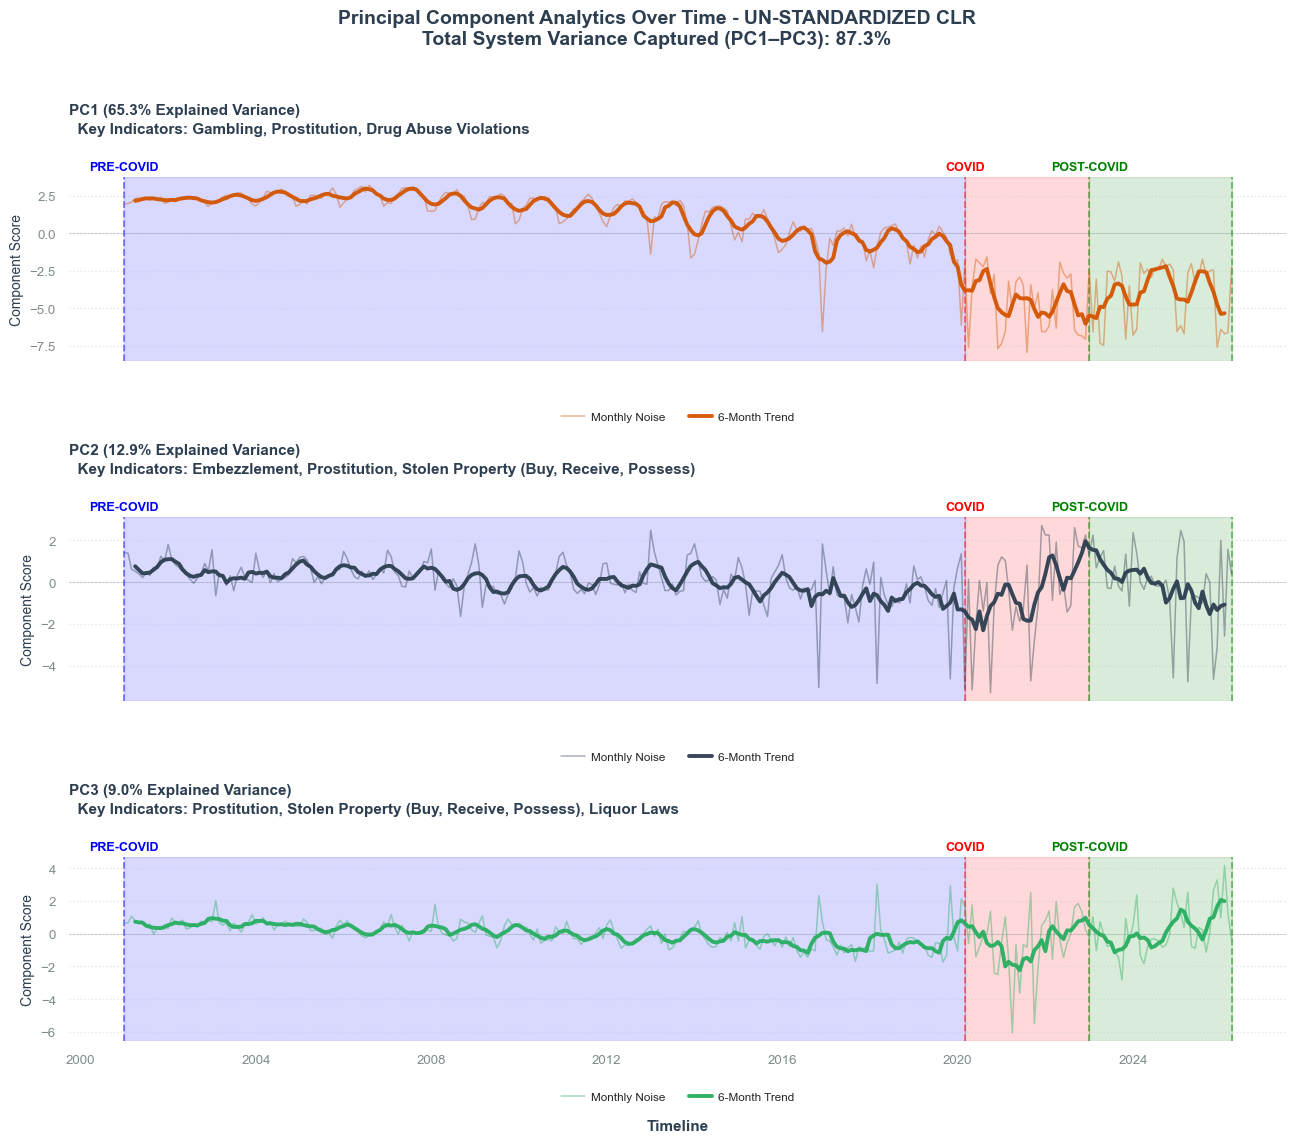

In [22]:
result_A_plot = plot.plot_pc_scores_over_time(pca_dict=pca_A,
                         panel_index=pca_A['observation_index'], 
                         title_suffix=' - Un-standardized CLR')

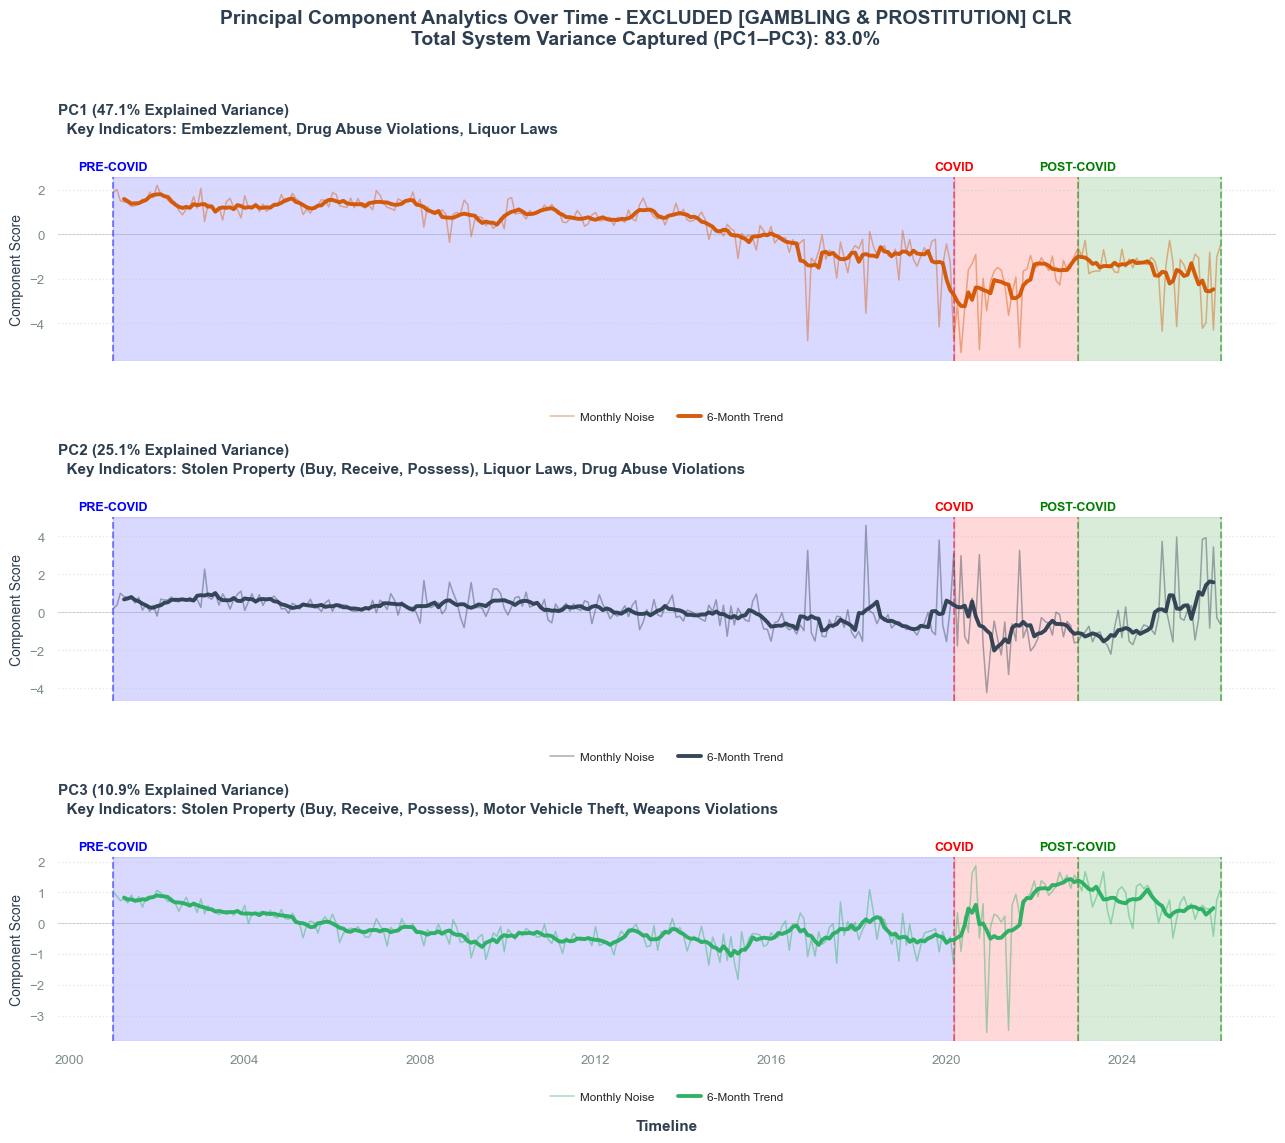

In [23]:
result_C_plot = plot.plot_pc_scores_over_time(pca_dict=pca_C,
                         panel_index=pca_A['observation_index'], 
                         title_suffix=' - excluded [Gambling & Prostitution] CLR')

#### 📌 Summary
> Across both versions of the dataset with and without vice-related categories, the principal components reveal a consistent pattern of structural change in Chicago's crime composition over time. In both analyses, PC1 exhibits a gradual pre-COVID decline followed by a visually pronounced break at the onset of the COVID era around March 2020, a pattern consistent with a structural discontinuity rather than a continuation of prior trends (formal changepoint testing is reported below). In the vice-removed analysis, PC3 provides a distinct COVID-aligned signal: relatively stable or declining before 2020, rising during the pandemic period, then partially reverting. Its dominant loadings on Stolen Property, Motor Vehicle Theft, and Weapons Violations point to a shift in the relative weight of these property and weapons offenses during the COVID era. The post-COVID period also shows evidence of lasting compositional change: in the vice-removed analysis, PC2 rises substantially from around 2022 and remains elevated, indeed still rising through the end of the series, indicating that the composition has not reverted to its pre-COVID structure. Together, the trajectories suggest three distinguishable compositional phases: a long-term pre-COVID decline, a sharp COVID-era disruption, and a post-COVID state that settles at a new compositional configuration rather than returning to historical patterns. Because the analysis is based on CLR-transformed data, the principal component scores reflect changes in relative compositional structure rather than changes in absolute crime levels.

### PCA Stability Diagnostic

In [24]:
# Iniutilize Alternative epsilon
epsilon_compare = [chosen_eps, prior_eps]
# Initialize Dictionary for outputs keyed by epsilon
results_pca = {}

# Loop over selected epsilon values and collect PC‑loading plots
for eps in epsilon_compare:

    # Generate the three‑PC loading plots for this epsilon
    r = pca_anchor.compute_pca(
        epsilon_sweep_result['clr_dict'][eps],
        epsilon=eps, verbose=True
    )

    # Store the result keyed by epsilon
    results_pca[eps] = r


             📊 PCA DATA MANIFEST (ε = 0.00894)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0


             📊 PCA DATA MANIFEST (ε = 0.00812)              
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                       25
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0



#### 📌 Summary

> For the dense subset, $\varepsilon = 0.008936$ was chosen as the smallest pseudocount that removed excessively large CLR values while still preserving rank stability. To test whether this choice was fragile, we compared it with the next lower value in the grid ($\varepsilon = 0.008117$). The PCA results were essentially identical across the boundary: PC1–PC3 matched almost perfectly (cosine similarity $\approx 1.0$), and the shared subspace rotated by only $0.29^\circ$. This shows that the analysis is stable and does not depend on the exact pseudocount selected near this threshold.

### Build Consensus

#### Aitchison Plot for the chosen epsilon

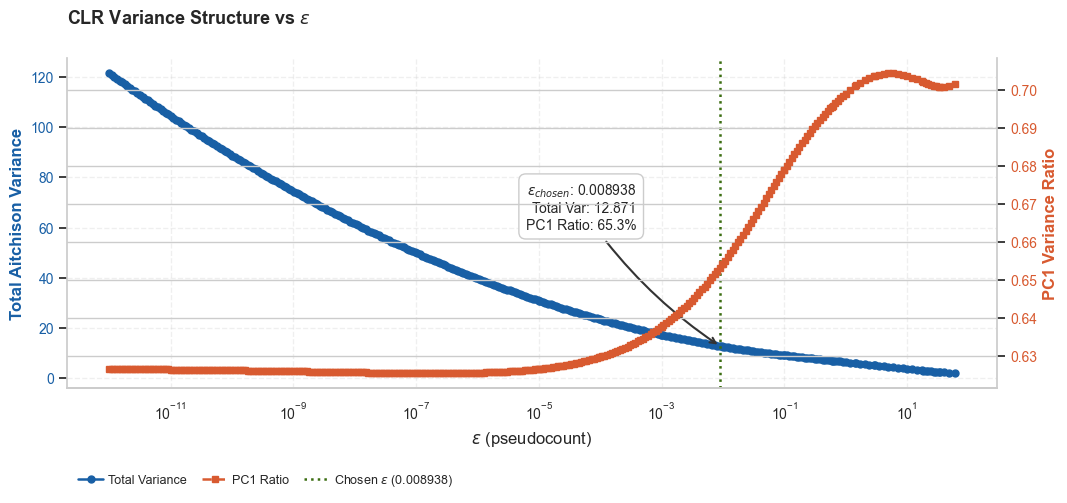

In [25]:
# Aitchison plot for the chosen epsilon (sweep_epsilon_grid() output dictionary:['clr_dict'])
aitchison_results = plot.plot_aitchison(epsilon_sweep_result['clr_dict'], chosen_eps)

#### Stability Diagnostics

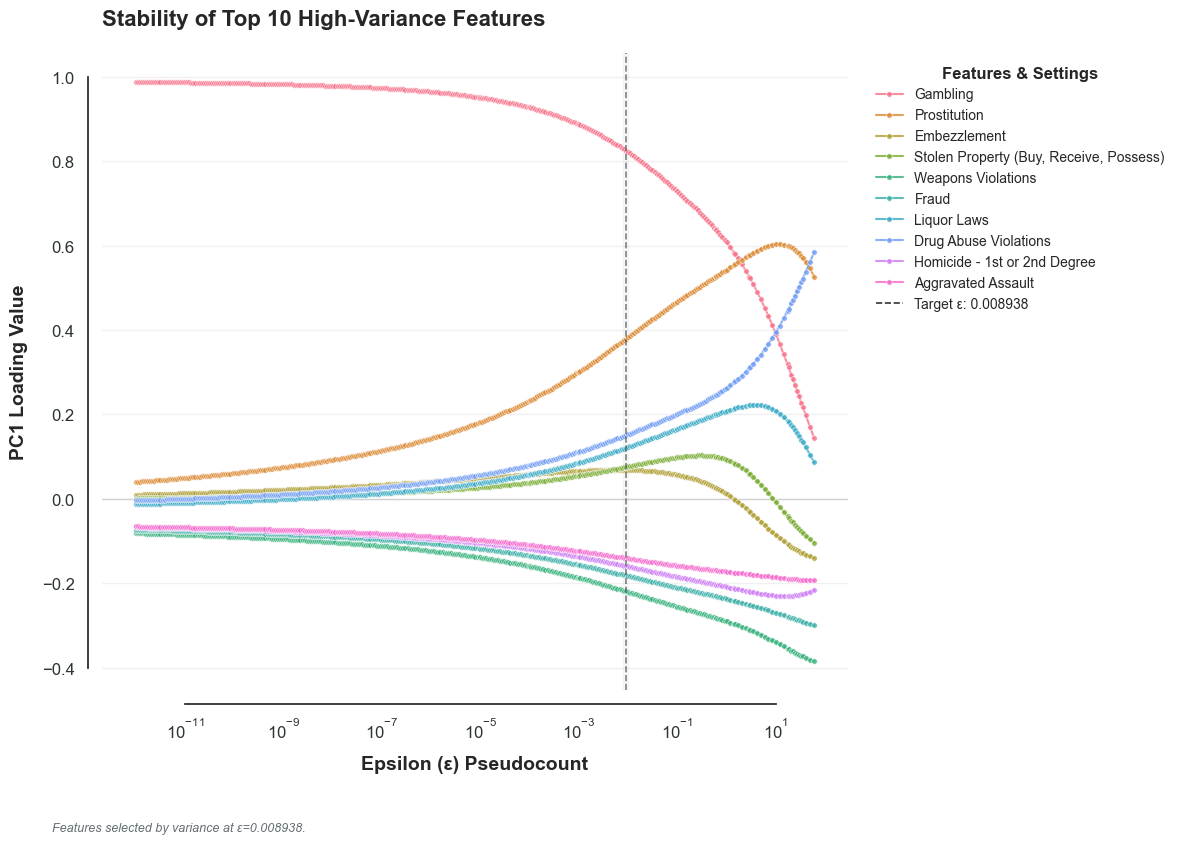

In [26]:
# PC Loading Stability Plot for the chosen epsilon for all
pc1_stability_results = plot.plot_pc1_loading_stability(epsilon_sweep_result['clr_dict'], chosen_eps=chosen_eps, top_k=10)

#### 📌 Summary

> Both PCA plots support the same overall conclusion and show that the selected pseudocount value ($\varepsilon = 0.008938$) produces meaningful and reliable results. The analysis shows that vice-related crimes—especially Gambling and Prostitution are the main drivers behind the first principal component (PC1), which explains about 65% of the overall variation in the crime composition data. When those vice categories are removed, the influence of PC1 drops noticeably to about 47%, confirming that they strongly shape the original pattern. The chosen $\varepsilon$ value is reasonable and avoids unstable or distorted behavior. One important note is that the exact percentages and category weights shift somewhat as $\varepsilon$ changes, so the specific numbers should be viewed as approximate rather than exact. Even so, the overall findings remain consistent: vice-related offenses dominate the original compositional structure. The vice-excluded specification serves as a robustness check, confirming that substantial co-movement structure persists even in the absence of these categories (PC1 $\approx$ 47%). The full 25-category analysis remains the primary specification, with the vice-excluded version providing a complementary check on the robustness of the findings.

## Inspect the CLR Dictionary Structure

In [27]:
# Inspect CLR dict structure
clr_dict = epsilon_sweep_result['clr_dict']
chosen_epsilon = chosen_eps

# Top-Level Diagnostics
print(f"\n📁 CLR DICTIONARY METADATA")
print("═" * 120)
print(f"Type:         {type(clr_dict)}")
print(f"Total Keys:   {len(clr_dict)}")

# Format keys to 6 decimal places for display
formatted_keys = [f"{float(k):.15f}" for k in list(clr_dict.keys())[:5]]
print(f"Keys (Head):  {formatted_keys} ...")


# Targeted Epsilon Drill-down
if chosen_epsilon in clr_dict:
    chosen_clr = clr_dict[chosen_epsilon]
    print(f"\n🔍 DRILL-DOWN: EPSILON = {chosen_epsilon:.15f}")
    print("═" * 120)
    print(f"Matrix Type:   {type(chosen_clr)}")
    print(f"Matrix Shape:  {chosen_clr.shape}")
    print(f"Total Columns: {len(chosen_clr.columns)}")
    
    # Format DatetimeIndex to YYYY-MM
    formatted_index = chosen_clr.index[:5].strftime('%Y-%m').tolist()
    print(f"Index (Head):  {formatted_index} ...")
    print(f"Columns (Head):{chosen_clr.columns[:5].tolist()} ...")
else:
    print(f"[ERROR] Epsilon {chosen_epsilon:.15f} is missing from the dictionary keys.")


📁 CLR DICTIONARY METADATA
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Type:         <class 'dict'>
Total Keys:   323
Keys (Head):  ['0.000000000001000', '0.000000000001101', '0.000000000001212', '0.000000000001335', '0.000000000001470'] ...

🔍 DRILL-DOWN: EPSILON = 0.008937571151054
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Matrix Type:   <class 'pandas.core.frame.DataFrame'>
Matrix Shape:  (304, 25)
Total Columns: 25
Index (Head):  ['2001-01', '2001-02', '2001-03', '2001-04', '2001-05'] ...
Columns (Head):['Aggravated Assault', 'Aggravated Battery', 'Arson', 'Burglary', 'Criminal Sexual Assault'] ...


### Build the CLR Matrix & Slice Into Eras

In [28]:
# Build CLR Matrix into Eras
clr_era = clr.slice_clr_into_eras(epsilon_sweep_result['clr_dict'], cfg.era_boundaries, eps=chosen_eps)


 📅  CLR TEMPORAL SEGMENTATION REPORT (ε = 0.00893757115105)
  • Total Matrix       : 304 months x 25 crimes
  • Date Horizon       : 2001-01 to 2026-04
------------------------------------------------------------
  Era Label          | Span (T)     | Date Range          
------------------------------------------------------------
  Pre-COVID          | 230 months   | 2001-01 to 2020-02
  COVID              | 34 months    | 2020-03 to 2022-12
  Post-COVID         | 40 months    | 2023-01 to 2026-04



### Compute Per-Era Distributional Parameters

In [29]:
# Compute Per-Era Distribution
eras_stat = clr.compute_era_distribution_parameters(clr_era, verbose=True)


MEAN CLR VECTOR PER ERA
                                         Pre-COVID   COVID  Post-COVID  COVID_minus_Pre-COVID  Post-COVID_minus_Pre-COVID  Post-COVID_minus_COVID
Aggravated Assault                          0.3776  1.3350      1.2376                 0.9574                      0.8600                 -0.0974
Aggravated Battery                          0.8448  1.4718      1.2893                 0.6270                      0.4445                 -0.1825
Arson                                      -1.9626 -1.2915     -1.5687                 0.6711                      0.3939                 -0.2772
Burglary                                    1.5947  1.3982      1.1890                -0.1964                     -0.4057                 -0.2092
Criminal Sexual Assault                    -0.7777 -0.0898     -0.1368                 0.6879                      0.6409                 -0.0470
Disorderly Conduct                         -0.1843 -0.5079     -0.2071                -0.3237      

#### 📌 Summary

> - The per-era analysis shows that Chicago's crime composition changed substantially between the pre-COVID, COVID, and post-COVID periods. The largest and most permanent shifts involved vice-related offenses. Gambling and Prostitution declined sharply during COVID and remained far below their pre-pandemic levels afterward, making them the strongest structural changes in the dataset. At the same time, violent and weapons-related offenses became relatively more prominent during the COVID era, including increases in Weapons Violations, Homicide, and Aggravated Assault. Some of these increases eased after COVID, but they did not fully return to earlier patterns. Motor Vehicle Theft showed the clearest long-term increase, rising steadily across all three periods without reversing. Fraud also increased during COVID, while Drug Abuse Violations declined.
> - The analysis also found that the COVID period was much more unstable and volatile than the years before or after it, especially for lower-frequency categories such as Gambling, Prostitution, Embezzlement, and Stolen Property. Most of this instability settled down after COVID, although Embezzlement remained unusually volatile compared with earlier years. Importantly, the study measures changes in the relative composition of crime categories rather than raw crime totals, meaning the results describe how the balance of offenses shifted within the overall crime system.
> - Overall, the findings point to three characteristically different periods: a relatively stable pre-COVID period, a sharp COVID-era disruption, and a post-COVID period that settled into a new structure rather than returning to the old one. Formal changepoint detection (below) tests whether these descriptive differences correspond to statistically significant structural breaks.

### Sanity Check
`era_covs_lw`: LW takes your noisy estimated relationships between crime types and asks, "How much of this is real signal vs. sampling noise?" It preserves the signal and reduces noise toward zero.

In [36]:
# Configuration for Audit Report (Sanity Check)
audit_config = {
    'era_covs': "Covariance Matrix Geometry",
    'era_means': "Era Mean Matrix Structure",
    'era_stds': "Era Std Deviation Matrix Structure"
}

width = 65
row_fmt = "  {:<35} | {:>22}"
divider = "─" * width

print("═" * width)
print(f"{'📋 DATA METRIC AUDIT REPORT':^{width}}")
print(f"{'Structural Dimensionality & Sanity Check':^{width}}")
print("═" * width)
print(row_fmt.format("Report Target / Node", "Dimensions"))
print(divider)

for key, title in audit_config.items():
    data = eras_stat.get(key)
    if data is None:
        continue

    # Section Header
    print(f"\n🔹 {title.upper()}")

    # Case A: Nested Era-Specific Covariance Dictionaries
    if isinstance(data, dict):
        items = list(data.items())
        for idx, (era, matrix) in enumerate(items):
            branch = "└── " if idx == len(items) - 1 else "├── "
            dim_str = f"{matrix.shape[0]} × {matrix.shape[1]} (Square)"
            print(row_fmt.format(f"{branch}{era}", dim_str))

    # Case B: Integrated DataFrames
    elif hasattr(data, 'shape'):
        rows, cols = data.shape
        print(row_fmt.format("├── Integrated Dataset", f"{rows} × {cols}"))
        print(row_fmt.format("├── Analyzed Features", f"{rows} Crime Categories"))
        print(row_fmt.format("└── Temporal Breakdown", "3 Eras + 3 Shift Metrics"))

    print(divider)

═════════════════════════════════════════════════════════════════
                   📋 DATA METRIC AUDIT REPORT                    
            Structural Dimensionality & Sanity Check             
═════════════════════════════════════════════════════════════════
  Report Target / Node                |             Dimensions
─────────────────────────────────────────────────────────────────

🔹 COVARIANCE MATRIX GEOMETRY
  ├── Pre-COVID                       |       25 × 25 (Square)
  ├── COVID                           |       25 × 25 (Square)
  └── Post-COVID                      |       25 × 25 (Square)
─────────────────────────────────────────────────────────────────

🔹 ERA MEAN MATRIX STRUCTURE
  ├── Integrated Dataset              |                 25 × 6
  ├── Analyzed Features               |    25 Crime Categories
  └── Temporal Breakdown              | 3 Eras + 3 Shift Metrics
─────────────────────────────────────────────────────────────────

🔹 ERA STD DEVIATION MATRIX STRUCTUR

## Visualize the Mean/Volatility CLR Shift Heatmap

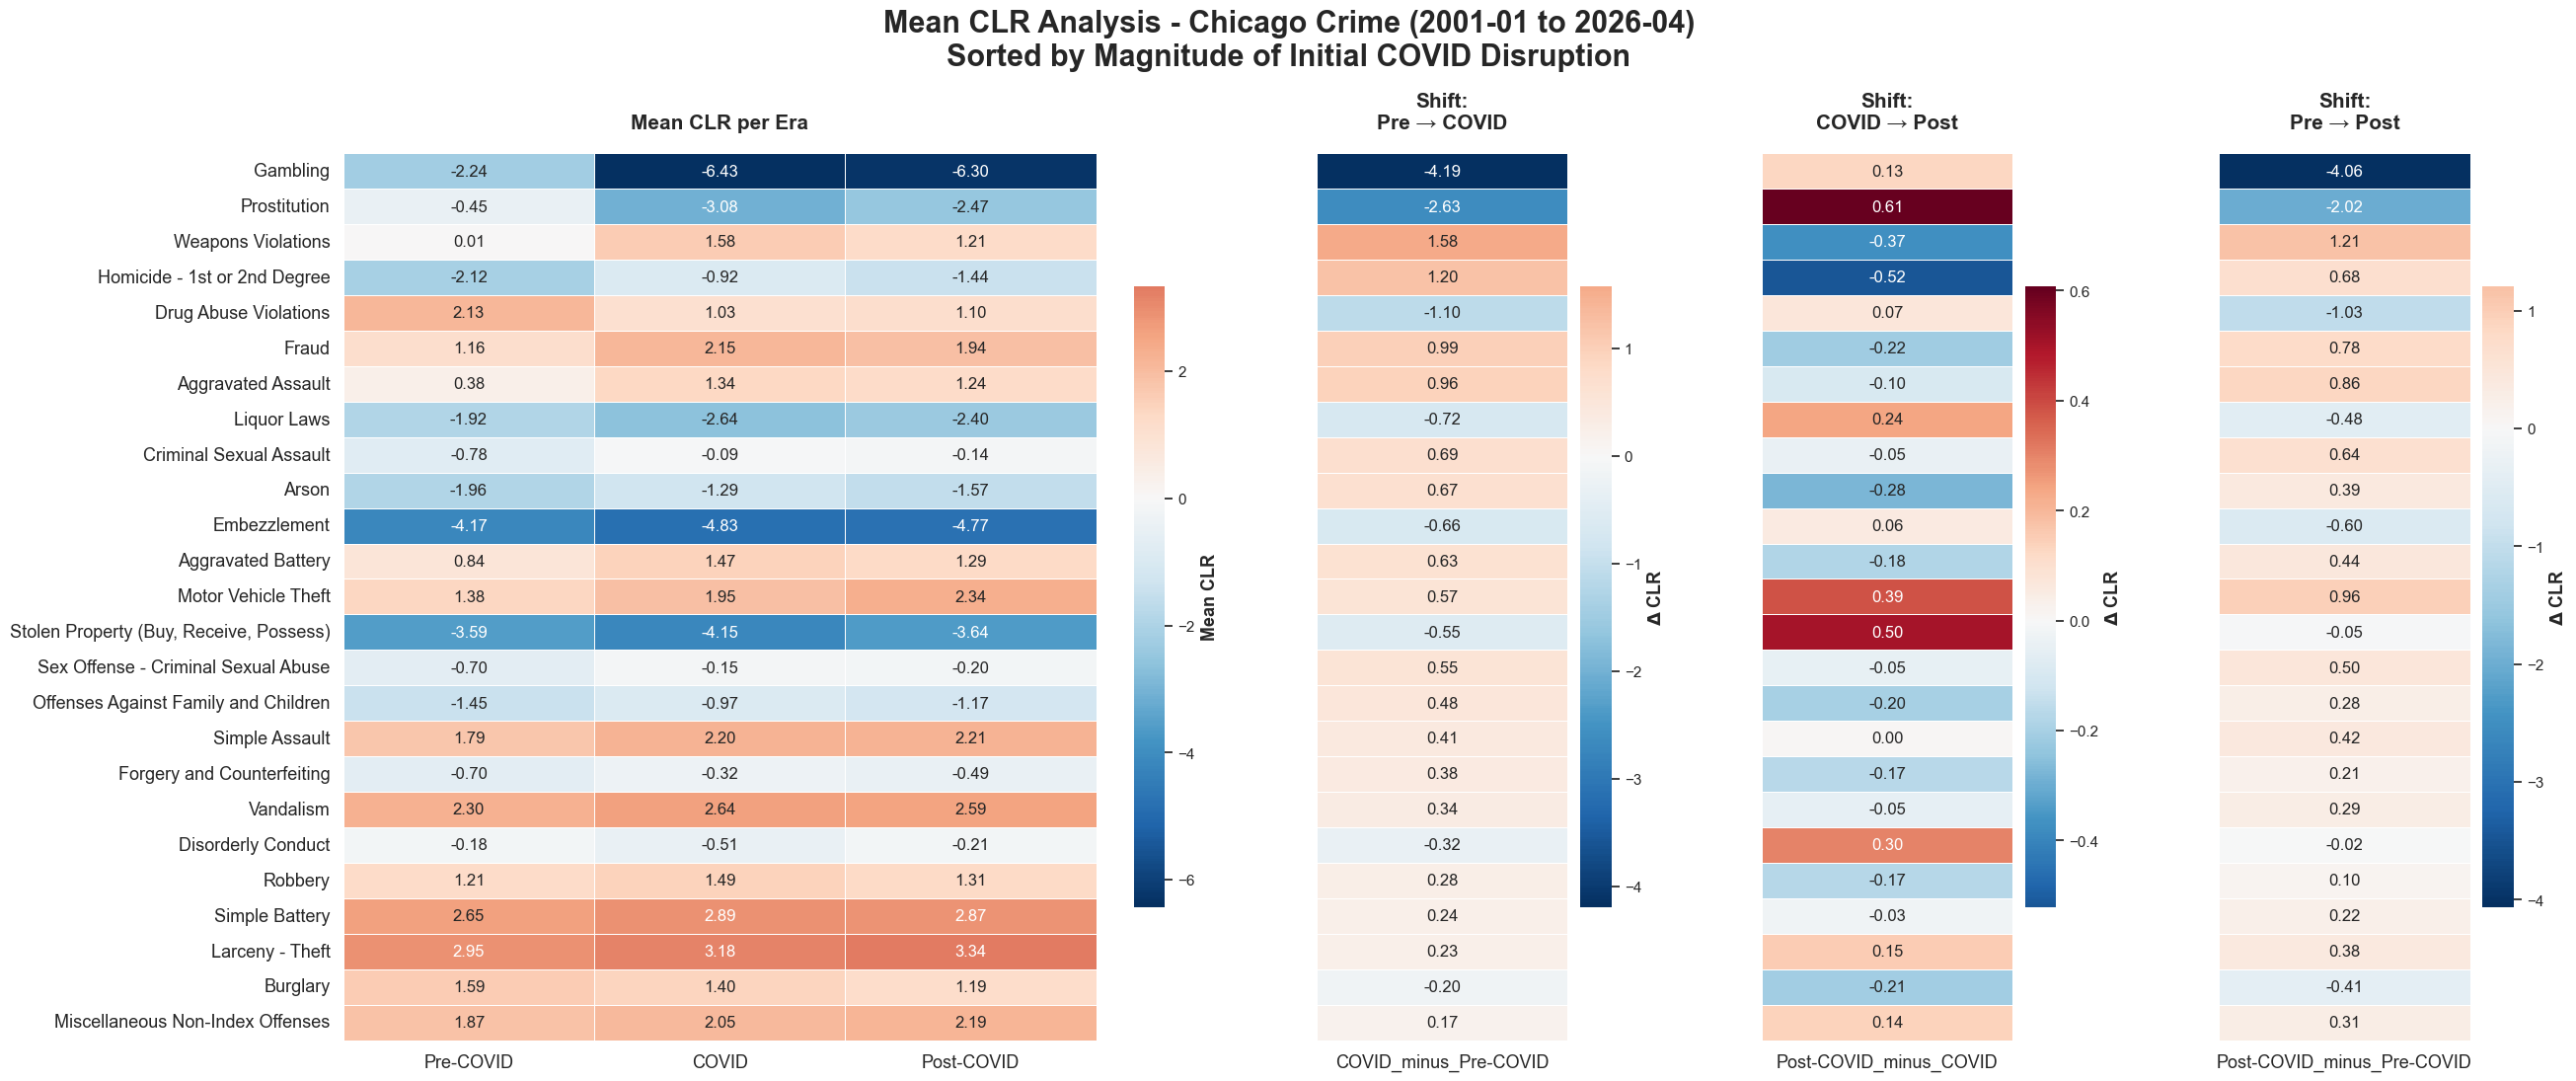

In [31]:
# Heat Map for Mean
plot.plot_era_heatmaps(eras_stat, stat_type='mean')

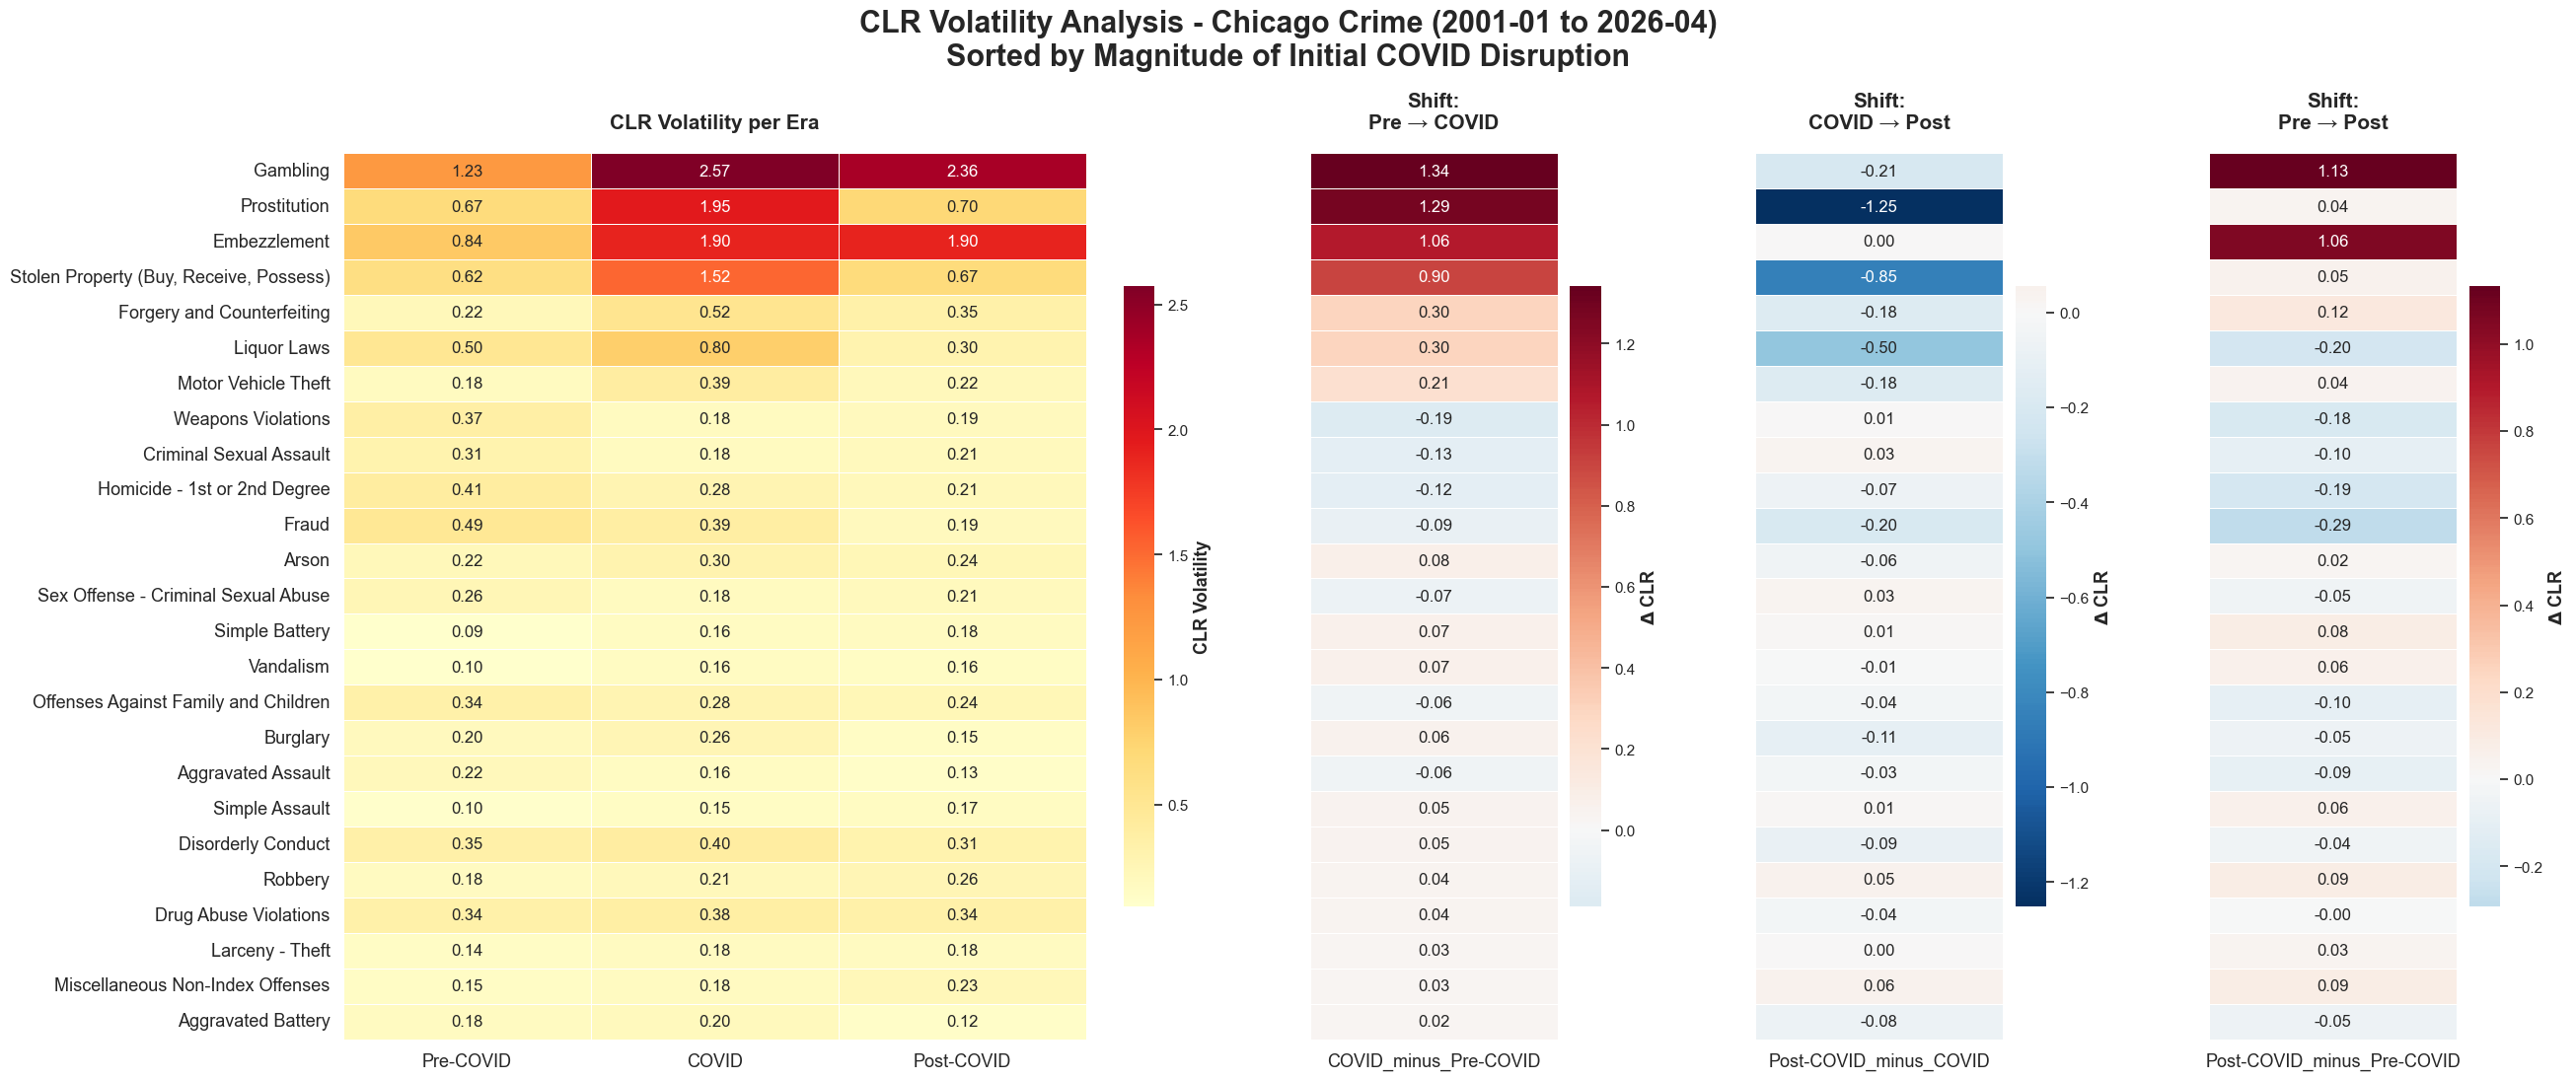

In [32]:
# Heat Map for Volatility
plot.plot_era_heatmaps(eras_stat, stat_type='std')

#### 📌 Summary

> - The mean and volatility heatmaps show that the COVID-era disruption was not evenly spread across all crime categories. Instead, the largest compositional changes were concentrated in four areas: Gambling, Prostitution, Embezzlement, and Stolen Property. These categories experienced much larger shifts than the rest of the system, creating a clear separation between the most disrupted offenses and all others. 
> - The volatility results also show that much of the instability observed during COVID later subsided, especially for Prostitution and Stolen Property, which moved closer to their pre-COVID behavior after the pandemic. Embezzlement, however, remained unusually volatile even after COVID, making it a notable exception.
> - The mean-shift results further show that the post-COVID period did not simply return to pre-pandemic conditions. Property-related offenses, especially Motor Vehicle Theft and Stolen Property, became relatively more prominent after COVID, while some of the sharp COVID-era increases in vice and weapons-related categories partially reversed. Together, these patterns suggest that Chicago entered a new post-COVID crime composition rather than returning to its earlier structure.

### Build & Check the CLR Matrix & Slice Into Eras

In [37]:
# Combined structural audit of CLR‑era matrices and the reconstructed wide‑format dataset
clr_df, raw_wide = utils.audit_clr_and_wide(clr_era = clr_era, fill_results=fill_results)

════════════════════════════════════════════════════════════════════════════════
                        📊 SYSTEM INTEGRITY AUDIT REPORT                         
               Structural Dimensionality & Alignment Verification               
════════════════════════════════════════════════════════════════════════════════
  Inspection Target Node                 |        Properties / Shapes
────────────────────────────────────────────────────────────────────────────────
 [ DATA MATRIX DIMENSIONALITY ]
    ├── Reconstructed CLR Space          |         304 Rows × 25 Cols
    └── Reference Filled Long Space      |        7,600 Rows × 5 Cols
────────────────────────────────────────────────────────────────────────────────
 [ TEMPORAL TIMELINE BOUNDARIES ]
    ├── Timeline Head (Start Window)     | ['2001-01', '2001-02', '2001-03'] …
    └── Timeline Tail (End Window)       | … ['2026-02', '2026-03', '2026-04']
────────────────────────────────────────────────────────────────────────────────

### Per-Category CLR Structural Distribution Plots

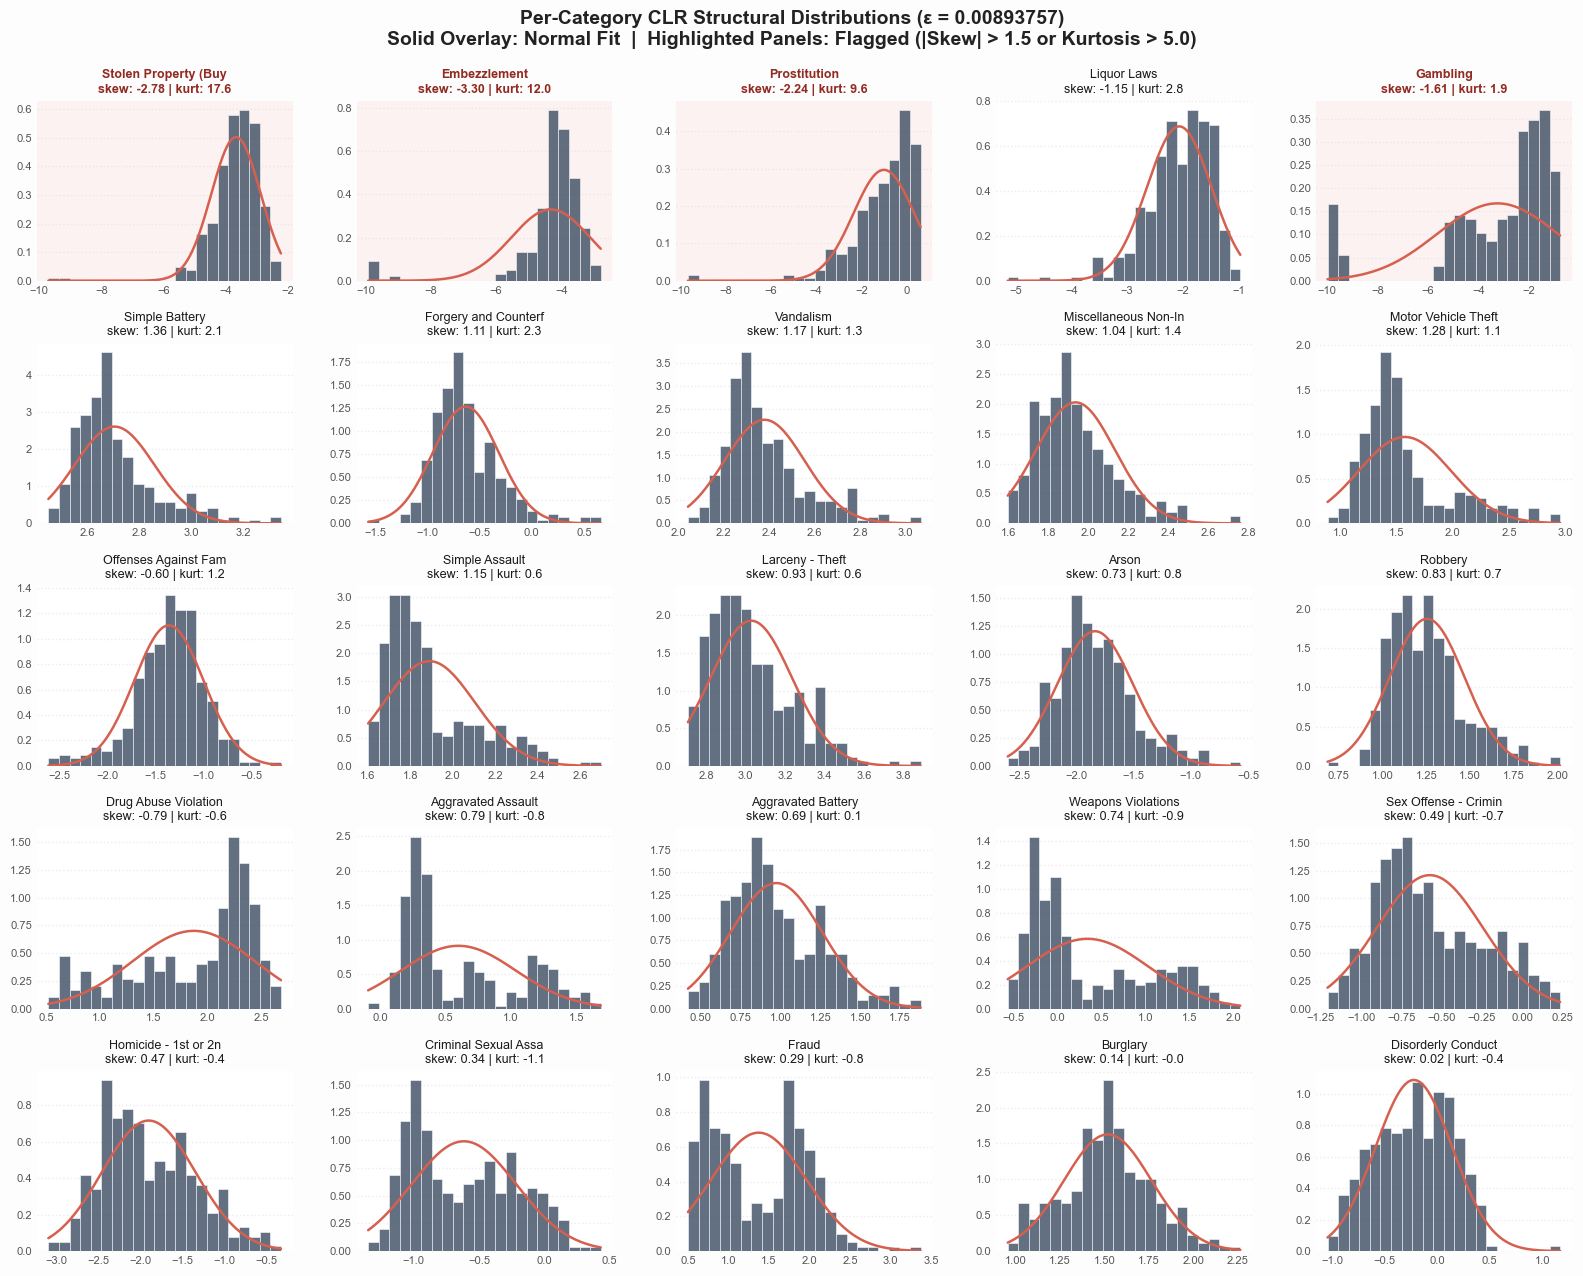

In [38]:
# Perform an optimized per‑category distribution audit on a CLR‑transformed dataset
diag_result = plot.check_clr_distributions(clr_df=clr_df, raw_counts=fill_results['filled_df'], epsilon=chosen_eps)

In [39]:
# The diagnostics table, worst-behaved categories first
print(diag_result.to_string(index=False))

# Just the flagged ones
flagged = diag_result[diag_result['flagged']]
print(f"\nFlagged categories ({len(flagged)}):")
print(flagged[['category', 'skew', 'excess_kurtosis', 'zero_rate_%']].to_string(index=False))

                               category  mean_clr  std_clr      skew  excess_kurtosis    shapiro_p  zero_rate_%  flagged
Stolen Property (Buy, Receive, Possess) -3.663087 0.793778 -2.782769        17.619585 8.355684e-18     0.657895     True
                           Embezzlement -4.325048 1.208186 -3.297230        11.995930 2.022205e-25     3.947368     True
                           Prostitution -1.008435 1.345903 -2.240166         9.636818 7.700895e-18     0.657895     True
                            Liquor Laws -2.062354 0.580347 -1.151303         2.784011 4.428174e-10     0.000000    False
                               Gambling -3.243736 2.389331 -1.610828         1.890027 9.983688e-20     9.210526     True
                         Simple Battery  2.705066 0.152478  1.363805         2.098409 9.910794e-14     0.000000    False
             Forgery and Counterfeiting -0.631556 0.315784  1.107361         2.259571 2.331467e-10     0.000000    False
                              Va

#### 📌 Summary

> The CLR distribution diagnostics at $\varepsilon = 0.008938$ show that the transformation performs well across nearly the entire dataset. Most crime categories (21 out of 25) display low skew and approximately normal distributions after transformation, indicating that the data are stable and suitable for compositional analysis. Only four lower-volume categories, Stolen Property, Embezzlement, Prostitution, and Gambling, show heavier tails and more uneven distributions. Importantly, the results suggest that these irregularities are not caused by the pseudocount itself. In fact, the sparsest category, Gambling, has relatively mild tail behavior, while Stolen Property, which rarely contains zeros, shows the strongest extremes. This pattern indicates that the heavy tails are driven by real-world spikes and structural changes in the data rather than mathematical distortion from the transformation. Overall, the findings support the conclusion that the selected ε value is appropriate and does not artificially distort even the sparse categories in the analysis.

## Stationarity Testing & Block Bootstrap on the CLR series 
The CLR-transformed series spans 304 months (Jan 2001 - April 2026) across three structurally distinct eras separated by known administrative breakpoints. Over this period, Chicago crime composition was subject to major policy shifts (gambling legalization, FOSTA-SESTA, CPD consent decree), demographic changes, and a global pandemic, all of which introduced sustained distributional shifts inconsistent with stationarity. Non-stationarity is therefore theoretically expected and consistent with the structural break detection framework adopted in this analysis. We will still conduct the test to determine whether the CLR-transformed series appears stationary or non-stationary.

**Note:**
>Standard ADF and KPSS tests assume no structural breaks and independent observations. Given the known breakpoints at months 230 (Feb 2020) and 264 (Dec 2022), compositional constraint across K=26 series, and structural zeros in sparse categories, results should be interpreted as indicative rather than definitive. Conflicting results between ADF and KPSS will be reported transparently.

### Step 6a: Stationarity Testing

In [40]:
# Stationarity - CLR
sts_df = clr.run_stationarity_analysis(clr_df, fill_results['filled_df'], era_boundaries=cfg.era_boundaries, 
                                       seasonal_cycle=12, sparse_threshold=0.05, verbose=True)


📊 STATIONARITY DASHBOARD Total: 25
  Dense  : 24 
  Sparse : 1   (@ > 5.0%)

-------------------------------------------------------------------------------
  ⚠️  Gambling                                :   9.2% zeros
-------------------------------------------------------------------------------

🔍 DETAILED STATIONARITY REPORT (Dense)
   Category                                     Status
--------------------------------------------- ---------------------------------
  🔴 Aggravated Assault                       │ Agree - Non-Stationary
  🔴 Aggravated Battery                       │ Agree - Non-Stationary
  🟢 Arson                                    │ Break-Induced Stationarity
  🔴 Burglary                                 │ Agree - Non-Stationary
  🔴 Criminal Sexual Assault                  │ Agree - Non-Stationary
  🔴 Disorderly Conduct                       │ Agree - Non-Stationary
  🔴 Drug Abuse Violations                    │ Agree - Non-Stationary
  🔴 Embezzlement                

In [41]:
# Initialize values
window  = 12
category = 'Arson'
row = sts_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Plot
plot.plot_structural_break(
    clr_df, 
    category, 
    break_date=za_date,
    window=window,
    za_stat=za_stat, 
    za_p_adj=za_p_adj, 
    era_boundaries=cfg.era_boundaries, 
    verbose=True
)

ValueError: era_boundaries must contain exactly 2 entries (defining 3 eras), got 3


                        STRUCTURAL BREAK DIAGNOSTIC: Gambling                        
  ▶ BREAK POINT     : 2020-01
  ▶ ZA STATISTIC    : -4.414
  ▶ ADJ P-VALUE     : N/A (SPARSE) | STATUS: UNRELIABLE (SPARSE)

  [ SEGMENT STATISTICS ]
              count      mean       std       min      max
  PRE-BREAK   229.0 -1.859244  1.134180 -8.580169 -0.37859
  POST-BREAK   76.0 -5.823375  2.103726 -9.023751 -2.85491

  ▶ MEAN SHIFT (Δ)  : -3.9641



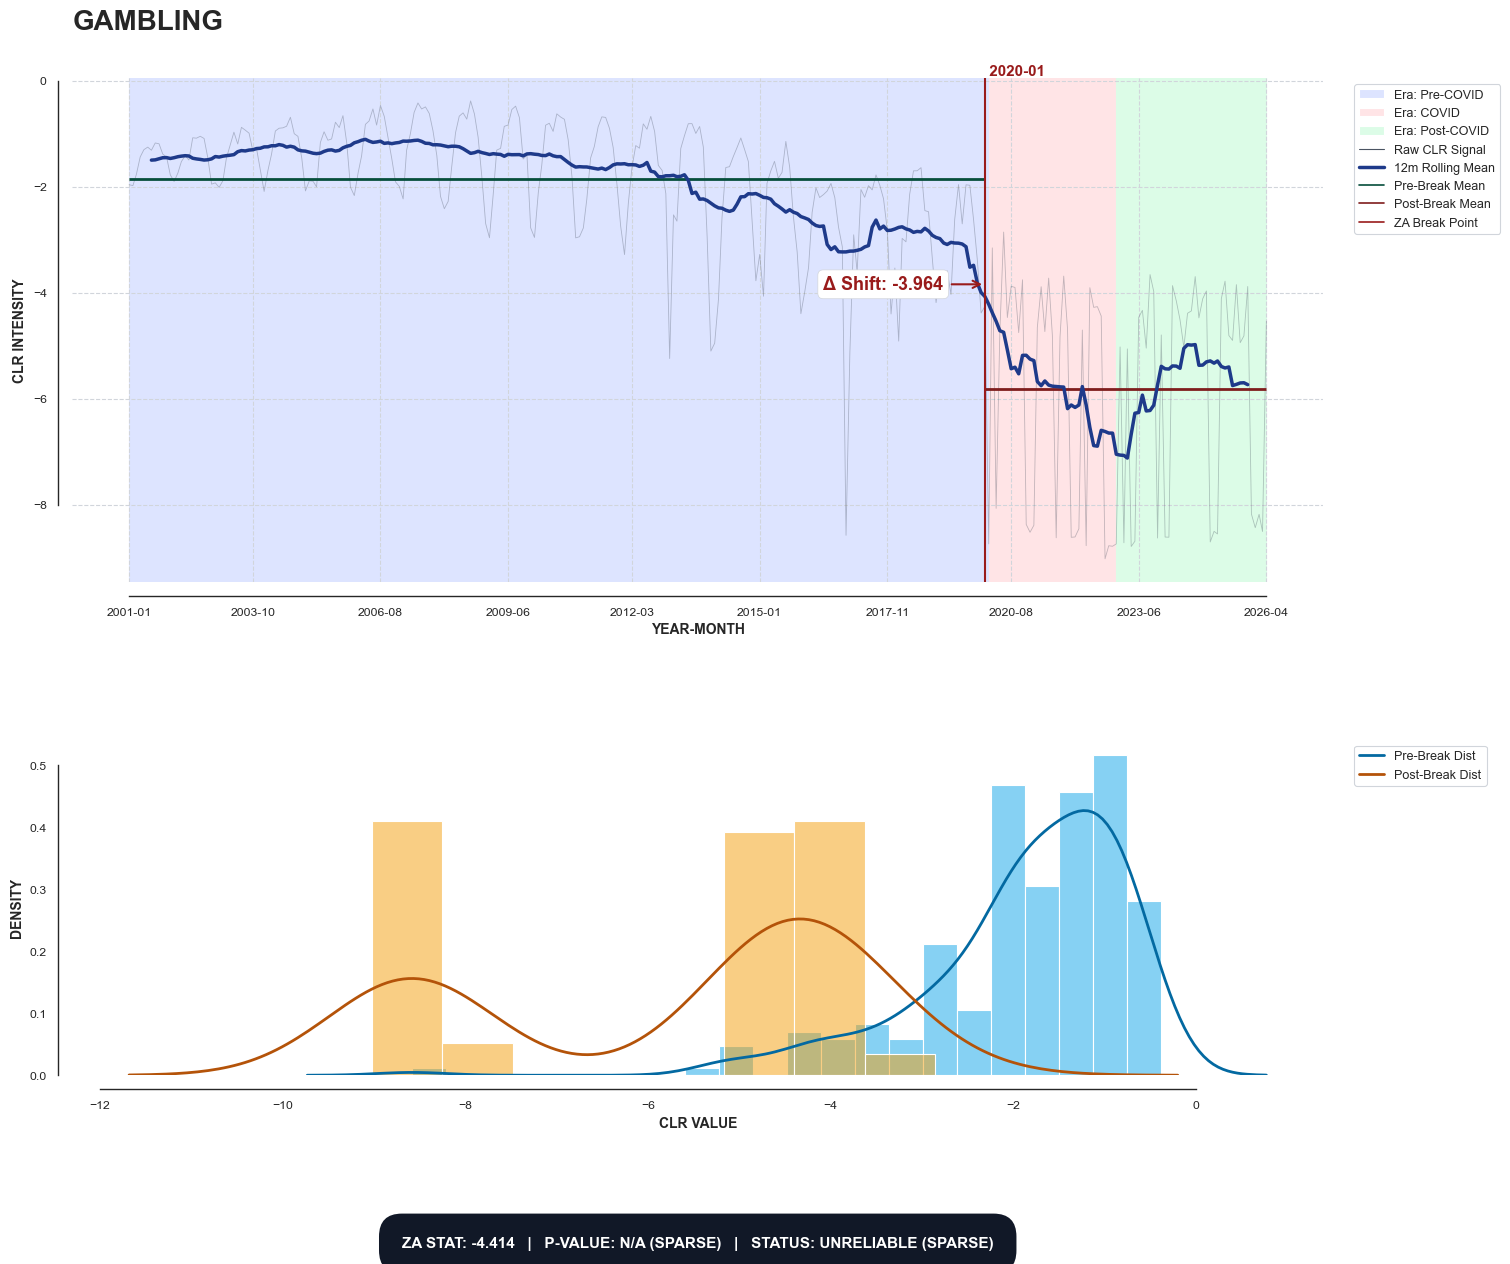

In [30]:
# Initialize values
category = 'Gambling'
row = sts_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Plot
# Fixed Function Call
plot.plot_structural_break(
    clr_df, 
    category, 
    break_date=za_date,
    window=window,
    za_stat=za_stat, 
    za_p_adj=za_p_adj, 
    era_boundaries=cfg.era_boundaries, 
    verbose=True
)

### Step 6b: Block Bootstrap Test

In [31]:
# Bootstrap Comparison of Eras
sparse_cats = [
    'Involuntary Manslaughter / Reckless Homicide', 'Gambling'
]

# Pre-COVID vs COVID
bootstrap_pc = clr.run_era_comparison(
    clr_era['Pre-COVID'], clr_era['COVID'],
    label1='Pre-COVID', label2='COVID',
    sparse_cats=sparse_cats,
    block_size=6,
    seed=_RANDOM_STATE, verbose=True
)


🧬 BOOTSTRAP INFERENCE: Pre-COVID vs COVID
📦 Blocks: 6 | 🔄 Iters: 10,000 | 👥 Groups: Pre-COVID vs COVID

CATEGORY                                Δ MEAN     HEDGES G      P-VAL    FDR ADJ   STATUS
────────────────────────────────────────────────────────────────────────────────────────────────────
Weapons Violations                      1.4763       4.5189     0.0001     0.0002   ✨ Significant
Aggravated Assault                      0.8558       4.5077     0.0001     0.0002   ✨ Significant
Drug Abuse Violations                  -1.2014      -3.2567     0.0001     0.0002   ✨ Significant
Homicide - 1st or 2nd Degree            1.0983       2.9836     0.0001     0.0002   ✨ Significant
Aggravated Battery                      0.5254       2.9800     0.0001     0.0002   ✨ Significant
Prostitution                           -2.6805      -2.9090     0.0001     0.0002   ✨ Significant
Gambling                               -3.9902      -2.8708     0.0001         --   📌 SPARSE/BYPASS
Simple Assault 

In [32]:
# COVID vs Post-COVID
bootstrap_cp = clr.run_era_comparison(
    clr_era['COVID'], clr_era['Post-COVID'],
    label1='COVID', label2='Post-COVID',
    sparse_cats=sparse_cats,
    block_size=6,
    seed=_RANDOM_STATE, verbose=True

)


🧬 BOOTSTRAP INFERENCE: COVID vs Post-COVID
📦 Blocks: 6 | 🔄 Iters: 10,000 | 👥 Groups: COVID vs Post-COVID

CATEGORY                                Δ MEAN     HEDGES G      P-VAL    FDR ADJ   STATUS
────────────────────────────────────────────────────────────────────────────────────────────────────
Homicide - 1st or 2nd Degree           -0.4677      -1.9702     0.0010     0.0240   ✨ Significant
Weapons Violations                     -0.3195      -1.7515     0.0026     0.0312   ✨ Significant
Motor Vehicle Theft                     0.4394       1.4756     0.0145     0.0821   🚫 Not Significant
Larceny - Theft                         0.2072       1.1645     0.0170     0.0821   🚫 Not Significant
Disorderly Conduct                      0.3539       0.9909     0.0263     0.1035   🚫 Not Significant
Miscellaneous Non-Index Offenses        0.1931       0.9763     0.0302     0.1035   🚫 Not Significant
Arson                                  -0.2241      -0.8364     0.0345     0.1035   🚫 Not Signifi

In [33]:
# Pre-COVID vs Post-COVID
bootstrap_pp = clr.run_era_comparison(
    clr_era['Pre-COVID'], clr_era['Post-COVID'],
    label1='Pre-COVID', label2='Post-COVID',
    sparse_cats=sparse_cats,
    block_size=6,
    seed=_RANDOM_STATE, verbose=True
)


🧬 BOOTSTRAP INFERENCE: Pre-COVID vs Post-COVID
📦 Blocks: 6 | 🔄 Iters: 10,000 | 👥 Groups: Pre-COVID vs Post-COVID

CATEGORY                                Δ MEAN     HEDGES G      P-VAL    FDR ADJ   STATUS
────────────────────────────────────────────────────────────────────────────────────────────────────
Motor Vehicle Theft                     0.9086       4.5706     0.0001     0.0001   ✨ Significant
Aggravated Assault                      0.8115       4.3086     0.0001     0.0001   ✨ Significant
Weapons Violations                      1.1567       3.5510     0.0001     0.0001   ✨ Significant
Simple Assault                          0.3692       3.1891     0.0001     0.0001   ✨ Significant
Drug Abuse Violations                  -1.0772      -2.9546     0.0001     0.0001   ✨ Significant
Prostitution                           -2.0677      -2.9242     0.0001     0.0001   ✨ Significant
Gambling                               -3.8528      -2.8177     0.0001         --   📌 SPARSE/BYPASS
Larce

📌 Summary

> Block-bootstrap inference across the three regime comparisons reveals a clear and persistent structural transition in the composition of crime in Chicago. The **Pre-COVID to COVID** transition produced widespread disruption where **23 of 24** dense crime categories shifted significantly after **BH-FDR correction**, with especially large standardized effects in violent crime categories such as Weapons Violations, Aggravated Assault, Homicide, and Aggravated Battery (all g > 2.9), alongside substantial declines in enforcement-discretionary categories including Drug Abuse Violations (g = −3.26), Prostitution (g = −2.91), and Liquor Laws (g = −1.42). The **COVID to Post-COVID** transition showed limited additional movement, with only Homicide and Weapons Violations exhibiting significant further change, both partially reverting from their COVID-era peaks. Despite this partial reversion, the **Pre-COVID to Post-COVID** comparison still identified significant differences across 20 of 24 dense categories, indicating that the post-pandemic crime structure did not return to its historical baseline and instead reflects a persistent reorganization of crime composition. Motor Vehicle Theft was a notable exception to the broader “shifted then stabilized” pattern, continuing to increase through the Post-COVID period and exhibiting the largest deviation from the Pre-COVID baseline observed in the study (g = 4.57). Two sparse categories were Gambling (9.2% zeros) and Involuntary Manslaughter / Reckless Homicide (76.6% zeros), which were excluded from formal inference because their CLR-based statistics would be dominated by zero-imputation effects. **Results should be interpreted with two caveats:** the 6-month dependence blocks preserve sub-annual autocorrelation but may not fully capture annual seasonality, and the 40-month Post-COVID window establishes medium-run persistence rather than long-run stability of the observed reorganization.

## Covariance Structure Analysis
```
Remove: Involuntary Manslaughter / Reckless Homicide :  76.6% zeros
        Gambling                                     :   9.2% zeros
```

In [35]:
# Sparse Cats
sparse_cats = ['Gambling', 'Involuntary Manslaughter / Reckless Homicide']

# Compute Per-Era Distribution
eras_stat_new = clr.compute_era_distribution_parameters(clr_era, sparse_cats=sparse_cats)

In [39]:
eras_stat_new.keys()

dict_keys(['era_names', 'era_means', 'era_stds', 'era_covs', 'era_covs_lw', 'lw_shrinkage', 'cond_numbers', 'pairs', 'sparse_cats', 'era_date_ranges'])

In [ ]:
# New PCA
pca_full_result = pca_anchor.compute_pca(epsilon_sweep_result['clr_dict'][epsilon], exclude_features=None)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================================
# Step 1 - DATA PREPARATION
# ======================================================================
def prepare_cov_matrices(eras_stat, clr_era):
    """Extract and validate all covariance matrices and CLR arrays."""
    era_map = {'Pre-COVID': 'pre_covid', 'COVID': 'covid', 'Post-COVID': 'post_covid'}
    matrices = {}
    
    print(f"{'='*70}\nCOVARIANCE STRUCTURE ANALYSIS\n{'='*70}")
    print(f"{'='*70}\nCOVARIANCE MATRIX VALIDATION\n{'='*70}")
    
    for era_name, clr_key in era_map.items():
        clr_mat = clr_era[clr_key]
        matrices[era_name] = {
            'clr': clr_mat,
            'T': len(clr_mat),
            'K': clr_mat.shape[1],
            'cov_raw': eras_stat['era_covs'][era_name].values,
            'cov_lw': eras_stat['era_covs_lw'][era_name].values,
            'lw_alpha': eras_stat['lw_shrinkage'].get(era_name, np.nan),
            'cols': clr_mat.columns.tolist()
        }
        # Success flag based on the standard 26x26 crime category matrix
        flag = '✅' if matrices[era_name]['cov_lw'].shape == (26, 26) else '❌'
        print(f"  {era_name:<15}: T={matrices[era_name]['T']:<4}  "
              f"cov_raw={matrices[era_name]['cov_raw'].shape}  "
              f"cov_lw={matrices[era_name]['cov_lw'].shape}  {flag}")
    return matrices

# ======================================================================
# Step 2 - STATISTICAL TEST
# ======================================================================
def run_boxm_test(matrices, n_permutations, seed, sparse_cats):
    """Performs Box's M test with a permutation-based p-value."""
    def get_stat(groups, ns, N, k):
        covs = [np.cov(g.T, ddof=1) for g in groups]
        S_pool = sum((n - 1) * S for n, S in zip(ns, covs)) / (N - k)
        _, ld_p = np.linalg.slogdet(S_pool)
        ld_i = [np.linalg.slogdet(S)[1] for S in covs]
        return (N - k) * ld_p - sum((n - 1) * ld for n, ld in zip(ns, ld_i))

    rng = np.random.default_rng(seed)
    era_keys = list(matrices.keys())
    groups = [matrices[e]['clr'].values for e in era_keys]
    ns = [g.shape[0] for g in groups]
    N, k, K = sum(ns), len(groups), groups[0].shape[1]

    M_obs = get_stat(groups, ns, N, k)
    all_data = np.vstack(groups)
    M_perm = np.zeros(n_permutations)
    splits = np.cumsum(ns)[:-1]

    for i in range(n_permutations):
        shuffled = rng.permutation(all_data)
        M_perm[i] = get_stat(np.split(shuffled, splits), ns, N, k)

    p_perm = np.mean(M_perm >= M_obs)
    
    print(f"\n{'='*70}\nBOX'S M TEST - EQUALITY OF COVARIANCE MATRICES\n{'='*70}")
    print(f"  Comparison    : {' vs '.join(era_keys)}")
    print(f"  Groups (k)    : {k} | Variables (K) : {K}")
    print(f"  Sample sizes  : {', '.join(f'{e}=T{n}' for e, n in zip(era_keys, ns))}")
    print(f"  Permutations  : {n_permutations:,}  seed={seed}")
    print(f"\n  M statistic   : {M_obs:.4f}")
    print(f"  p (permuted)  : {p_perm:.4f}  "
          f"{'✅ reject H₀ - structures differ' if p_perm < 0.05 else '❌ fail to reject H₀'}")
    print(f"\n  H₀: Σ_pre = Σ_covid = Σ_post\n  H₁: At least one covariance matrix differs")
    
    if sparse_cats:
        sparse_cats = list(set(sparse_cats))
        print(f"\n  Note: {len(sparse_cats)} sparse categories flagged ⚠️:")
        for cat in sorted(sparse_cats): print(f"    {cat}")

# ======================================================================
# Step 3 - ORCHESTRATOR
# ======================================================================
def run_covariance_structure_analysis(eras_stat, clr_era, sparse_cats=None, 
                                      n_permutations=10_000, seed=1776, 
                                      show_plots=False, save_path=None):
    """
    Unified Orchestrator. show_plots: bool, default False.
    """
    
    # PHASE 1: TEXT REPORT (Strict Sequential Order)
    sparse_cats = list(set(sparse_cats)) if sparse_cats is not None else []
    matrices = prepare_cov_matrices(eras_stat, clr_era)
    run_boxm_test(matrices, n_permutations, seed, sparse_cats)

    print(f"\n{'='*70}\nLOG-DETERMINANT COMPARISON - GENERALIZED VARIANCE\n{'='*70}")
    print(f"  {'Era':<12} {'log|Σ_raw|':>14} {'log|Σ_lw|':>14} {'T':>6} {'T/K':>8}  Status")
    print(f"  {'-' * 68}")

    ld_lw = {}
    for era_name in ['Pre-COVID', 'COVID', 'Post-COVID']:
        d = matrices[era_name]
        r = np.linalg.slogdet(d['cov_raw'])[1]
        l = np.linalg.slogdet(d['cov_lw'])[1]
        tk = d['T'] / d['K']
        flag = '✅' if tk >= 5 else '⚠️'
        print(f"  {era_name:<12} {r:>14.4f} {l:>14.4f} {d['T']:>6} {tk:>8.2f}  {flag}")
        ld_lw[era_name] = l

    print(f"\n  Δ log|Σ_lw| (LW - used for interpretation):")
    print(f"    COVID_minus_Pre   : {ld_lw['COVID'] - ld_lw['Pre-COVID']:+.4f}")
    print(f"    Post_minus_COVID  : {ld_lw['Post-COVID'] - ld_lw['COVID']:+.4f}")
    print(f"    Post_minus_Pre    : {ld_lw['Post-COVID'] - ld_lw['Pre-COVID']:+.4f}")
    print(f"\n  Interpretation:")
    print(f"    Positive Δ -> space EXPANDED | Negative Δ -> space CONTRACTED")

    # Native flush=True ensures all text hits the screen before plot data starts processing
    print(f"\n{'='*70}\nCOVARIANCE STRUCTURE ANALYSIS COMPLETE\n{'='*70}", flush=True)

    # PHASE 2: DATA CALCULATION & PLOTTING
    cols = matrices['Pre-COVID']['cols']
    # labeled = [f"{c} ⚠️" if c in (sparse_cats or []) else c for c in cols]
    labeled = [f"{c} (SPARSE)" if c in (sparse_cats or []) else c for c in cols]
    
    def get_corr_df(cov, labels):
        std = np.sqrt(np.diag(cov))
        return pd.DataFrame(cov / np.outer(std, std), index=labels, columns=labels)

    corrs = {e: get_corr_df(matrices[e]['cov_lw'], labeled) for e in matrices}

    if show_plots:
            # Get the actual number of categories remaining
            num_vars = len(cols)
            
            # 1. Absolute Correlation Heatmaps
            fig1, axes1 = plt.subplots(1, 3, figsize=(30, 10))
            for ax, e in zip(axes1, matrices.keys()):
                sns.heatmap(corrs[e], ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
                ax.set_title(f"{e} (α={matrices[e]['lw_alpha']:.4f})", fontweight='bold')
            
            plt.suptitle('Absolute CLR Correlation Matrices (LW Regularized)', fontweight='bold', fontsize=16)
            plt.tight_layout()
            if save_path: plt.savefig(f"{save_path}corr_absolute.png")
            plt.show()
    
            # 2. Delta Correlation Heatmaps
            fig2, axes2 = plt.subplots(1, 3, figsize=(30, 10))
            diffs = [
                corrs['COVID'] - corrs['Pre-COVID'], 
                corrs['Post-COVID'] - corrs['COVID'], 
                corrs['Post-COVID'] - corrs['Pre-COVID']
            ]
            titles = ["COVID − Pre-COVID", "Post-COVID − COVID", "Post-COVID − Pre-COVID (Net Change)"]
            
            # Create a dynamic mask based on the current matrix size (removes the diagonal)
            mask = np.eye(num_vars, dtype=bool)
            
            for ax, d, t in zip(axes2, diffs, titles):
                sns.heatmap(d, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1, 
                            square=True, mask=mask)
                ax.set_title(t, fontweight='bold')
                
            plt.suptitle('Delta CLR Correlation Matrices (LW Regularized)', fontweight='bold', fontsize=16)
            plt.tight_layout()
            if save_path: plt.savefig(f"{save_path}corr_delta.png")
            plt.show()
    
    return {'matrices': matrices, 'corrs': corrs, 'ld_lw': ld_lw}

In [36]:
from sklearn.covariance import LedoitWolf

def filtered_cov_matrices(clr_origin, sparse_cats):
    """Recalculates covariance matrices based on the columns currently in clr_era."""
    matrices = {}
    era_map = cfg.era_map

    # 1. Filter the dataframes first
    filtered_clr_era = {
        era_name: df.drop(columns=sparse_cats, errors='ignore') 
        for era_name, df in clr_origin.items()
    }
    
    print(f"{'='*70}\nRECALCULATING COVARIANCE STRUCTURE (Filtered)\n{'='*70}")
    
    for era_name, clr_key in era_map.items():
        # This is your filtered data (24 columns)
        clr_mat = filtered_clr_era[clr_key]
        
        # We must re-run Ledoit-Wolf on the filtered data 
        # so the matrix shape matches the new column count (24x24)
        lw = LedoitWolf().fit(clr_mat)
        
        matrices[era_name] = {
            'filtered_clr_era': filtered_clr_era,
            'clr': clr_mat,
            'T': len(clr_mat),
            'K': clr_mat.shape[1],
            'cov_raw': clr_mat.cov().values, # Matches filtered shape
            'cov_lw': lw.covariance_,        # Matches filtered shape
            'lw_alpha': lw.shrinkage_,
            'cols': clr_mat.columns.tolist()
        }
        
        flag = '✅' if matrices[era_name]['K'] == 24 else '⚠️'
        print(f"  {era_name:<15}: T={matrices[era_name]['T']:<4}  "
              f"K={matrices[era_name]['K']:<3}  "
              f"cov_lw={matrices[era_name]['cov_lw'].shape}  {flag}")
              
    return matrices

In [37]:
clr_new = filtered_cov_matrices(clr_era, sparse_cats)

RECALCULATING COVARIANCE STRUCTURE (Filtered)
  pre_covid      : T=230   K=24   cov_lw=(24, 24)  ✅
  covid          : T=34    K=24   cov_lw=(24, 24)  ✅
  post_covid     : T=40    K=24   cov_lw=(24, 24)  ✅


In [37]:
# Sparse Crime Types
sparse_cats = [
    'Involuntary Manslaughter / Reckless Homicide',
    'Gambling', 
]

# 1. Filter the dataframes first
filtered_clr_era = {
    era_name: df.drop(columns=sparse_cats, errors='ignore') 
    for era_name, df in clr_era.items()
}

# 2. Run the analysis on the 24 categories (excluding the 2 sparse ones)
cov_results_local = clr.run_covariance_structure_analysis(
    eras_stat       = eras_stat,
    clr_era         = filtered_clr_era,  # Pass the filtered dict here
    sparse_cats     = sparse_cats,       # This is now just for labeling the report
    n_permutations  = 10_000,
    seed            = _RANDOM_STATE
)


COVARIANCE STRUCTURE ANALYSIS
COVARIANCE MATRIX VALIDATION
  Pre-COVID      : T=230   cov_raw=(26, 26)  cov_lw=(26, 26)  ❌
  COVID          : T=34    cov_raw=(26, 26)  cov_lw=(26, 26)  ❌
  Post-COVID     : T=40    cov_raw=(26, 26)  cov_lw=(26, 26)  ❌

BOX'S M TEST - EQUALITY OF COVARIANCE MATRICES
  Comparison    : Pre-COVID vs COVID vs Post-COVID
  Groups (k)    : 3
  Variables (K) : 24
  Sample sizes  : Pre-COVID=T230, COVID=T34, Post-COVID=T40
  Permutations  : 10,000  seed=1776

  M statistic   : 2896.5187
  p (permuted)  : 0.0000  ✅ reject H₀ - structures differ

  H₀: Σ_pre = Σ_covid = Σ_post
  H₁: At least one covariance matrix differs

  Note: 2 sparse categories included in matrix, flagged ⚠️:
    Gambling
    Involuntary Manslaughter / Reckless Homicide



ValueError: Shape of passed values is (26, 26), indices imply (24, 24)


COVARIANCE STRUCTURE ANALYSIS
COVARIANCE MATRIX VALIDATION
  Pre-COVID      : T=230   cov_raw=(26, 26)  cov_lw=(26, 26)  ✅
  COVID          : T=34    cov_raw=(26, 26)  cov_lw=(26, 26)  ✅
  Post-COVID     : T=40    cov_raw=(26, 26)  cov_lw=(26, 26)  ✅

BOX'S M TEST - EQUALITY OF COVARIANCE MATRICES
  Comparison    : Pre-COVID vs COVID vs Post-COVID
  Groups (k)    : 3
  Variables (K) : 26
  Sample sizes  : Pre-COVID=T230, COVID=T34, Post-COVID=T40
  Permutations  : 10,000  seed=1776

  M statistic   : 3130.9071
  p (permuted)  : 0.0000  ✅ reject H₀ - structures differ

  H₀: Σ_pre = Σ_covid = Σ_post
  H₁: At least one covariance matrix differs



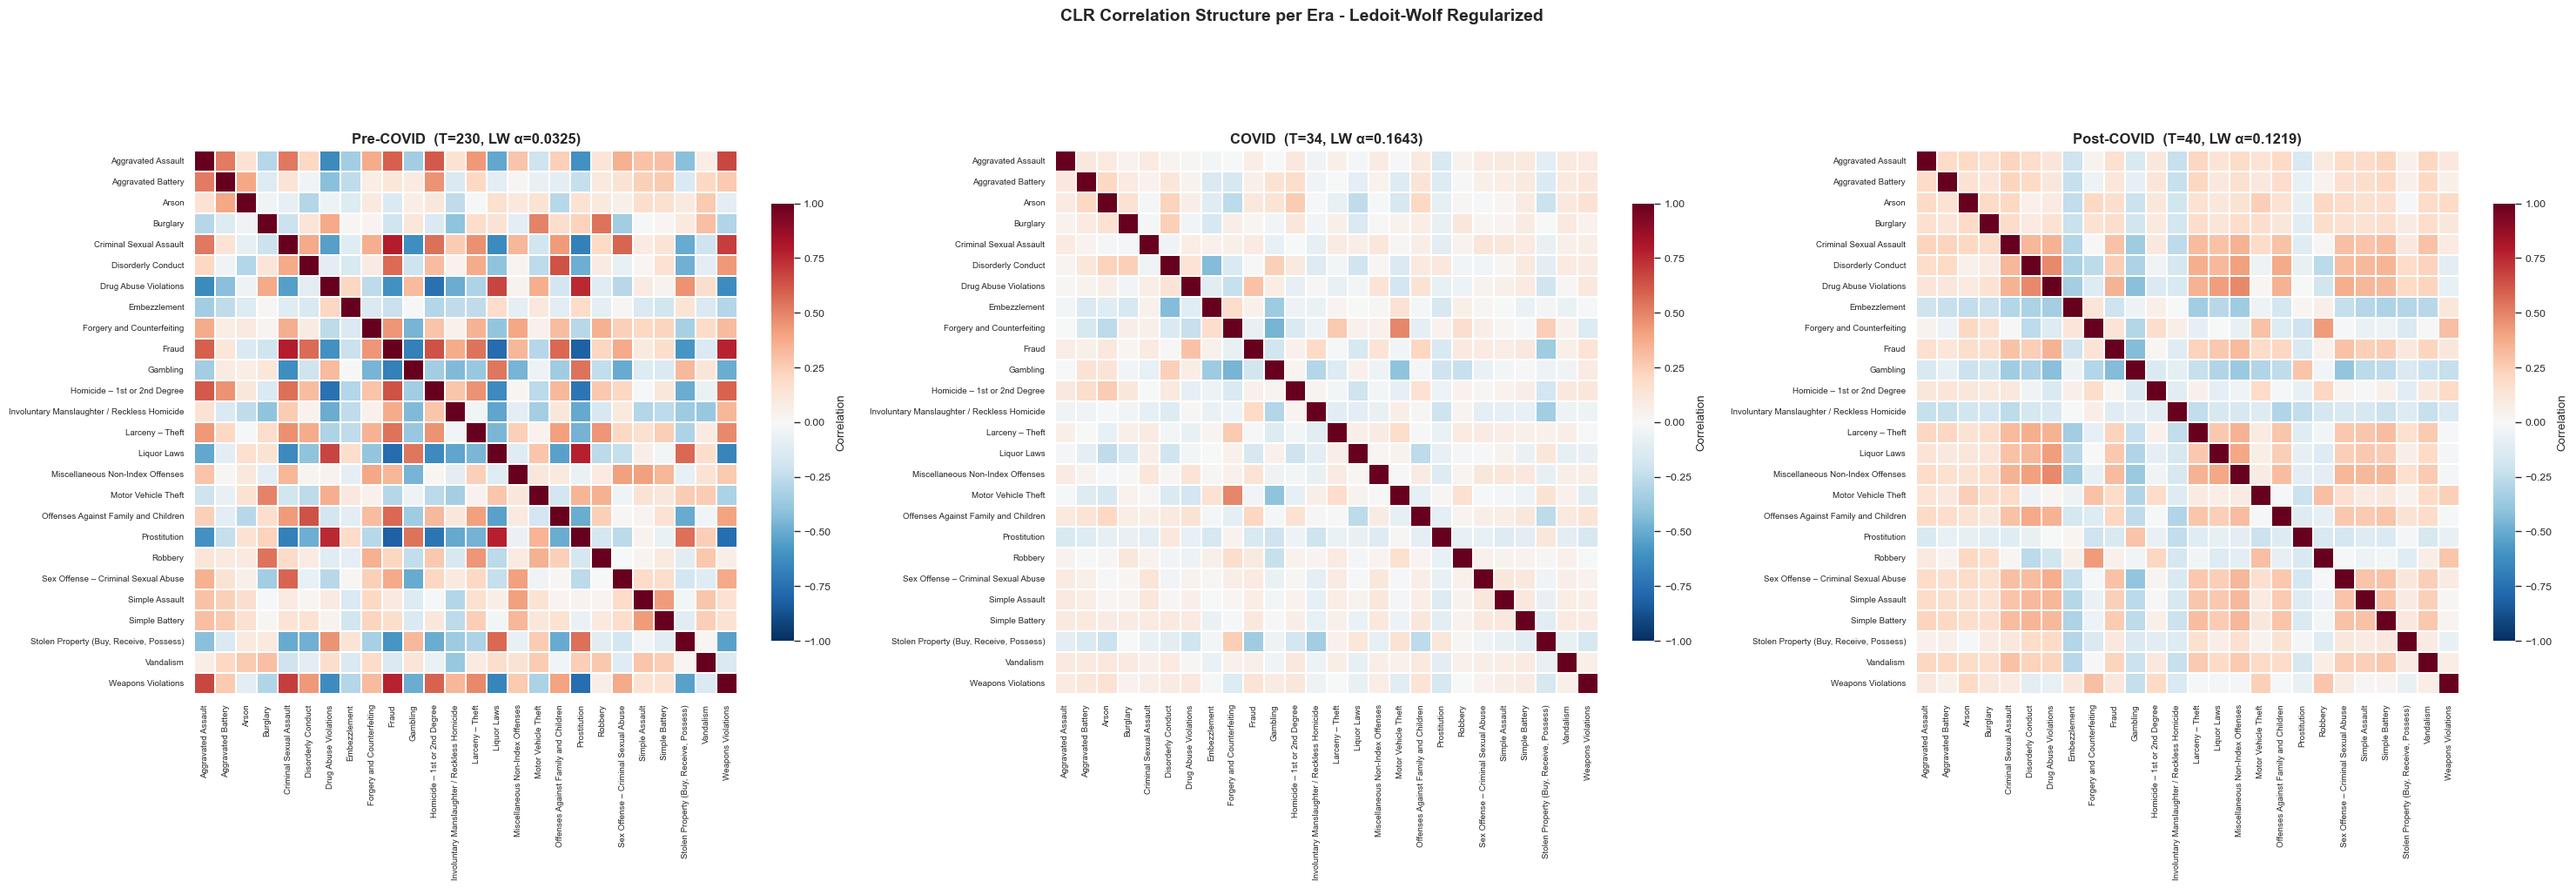

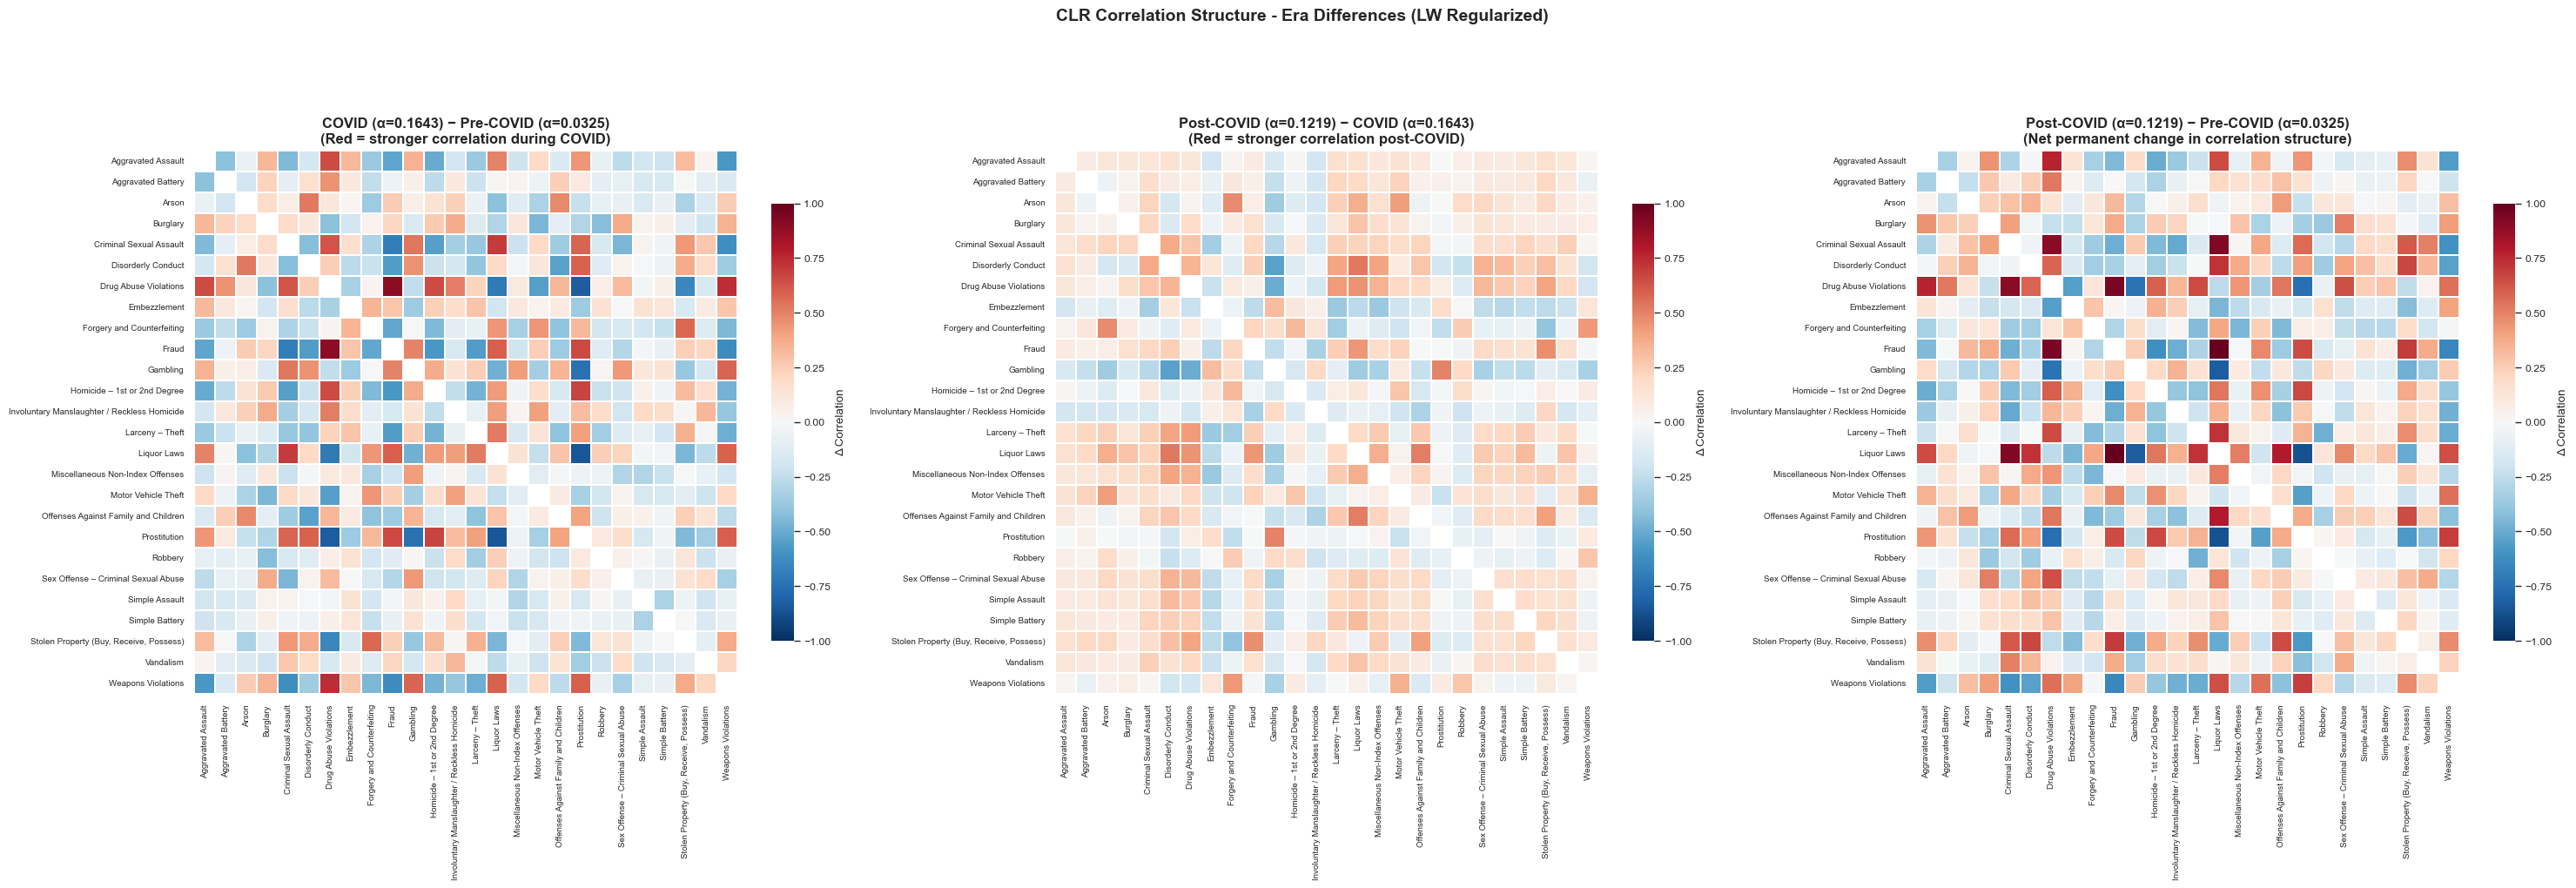


LOG-DETERMINANT COMPARISON - GENERALIZED VARIANCE
  Era                 log|Σ_raw|      log|Σ_lw|      T      T/K  Status
  --------------------------------------------------------------
  Pre-COVID            -129.6863       -78.9252    230     8.85  ✅
  COVID                -126.5965       -35.2641     34     1.31  ⚠️
  Post-COVID           -140.7346       -55.1377     40     1.54  ⚠️

  Δ log|Σ_lw| (LW - used for interpretation):
    COVID − Pre-COVID  : +43.6611
    Post  − COVID      : -19.8736
    Post  − Pre-COVID  : +23.7875

  Interpretation:
    Positive Δ -> crime space EXPANDED (more diverse)
    Negative Δ -> crime space CONTRACTED (more co-moving)

  Note: raw log|Σ| unreliable for COVID/Post-COVID
        (T/K < 5, CLR rank deficiency). Use LW values.

COVARIANCE STRUCTURE ANALYSIS COMPLETE


In [55]:
# Sparse Crime Types
sparse_cats = [
    'Involuntary Manslaughter / Reckless Homicide',
    'Gambling'
]
# Run test
cov_results = clr.run_covariance_structure_analysis(
    eras_stat       = eras_stat,
    clr_era         = clr_era,
    # sparse_cats     = sparse_cats,
    n_permutations  = 10_000,
    seed            = _RANDOM_STATE,
    save_path       = image_path
)

### Methodological Note

Box’s M test with permutation inference on shrinkage-adjusted covariance matrices strongly rejects equality of covariance structures across Pre-COVID, COVID, and Post-COVID periods, indicating that the relationships between crime categories change significantly over time. However, due to differing levels of shrinkage across eras and small sample sizes in the COVID and Post-COVID periods, log-determinant differences should be interpreted with caution as relative changes in regularized covariance dispersion rather than absolute changes in system diversity. Overall, the results consistently indicate that the dependency structure among crime categories is not stable across eras and undergoes a significant regime shift during and after COVID.

---

### Formal Test - Box's M

Box’s M test with 10,000 permutation iterations (seed=1776) tests whether covariance matrices are equal across the three eras. The observed M statistic of 3,130.91 yields a permutation p-value of 0.0000, leading to rejection of the null hypothesis that the covariance matrices are equal ($H_0: \Sigma_{\text{pre}} = \Sigma_{\text{covid}} = \Sigma_{\text{post}}$). This indicates that the dependency structure of crime composition differs significantly across eras. These differences are consistent with, but not identical to, the changes in marginal crime levels identified in the block-bootstrap analysis, since Box’s M specifically targets the covariance structure rather than the means. Three sparse categories (Gambling, Involuntary Manslaughter) are included in the covariance computation but flagged as unstable; their presence may influence the magnitude of the test statistic, so results should be interpreted primarily as evidence of broad structural differences rather than as effects driven by any individual category.

---

### Generalized Variance - Log-Determinant

The log-determinant of a covariance matrix quantifies the overall dispersion of the multivariate distribution in the 26-dimensional CLR space. Higher values indicate greater generalized variance in the joint movement of crime categories, while lower values indicate tighter co-movement among categories.

```
log|Σ_lw|:
  Pre-COVID  : −78.93   baseline
  COVID      : −35.26    Δ = +43.66 vs Pre-COVID
  Post-COVID : −55.14    Δ = −19.87 vs COVID
                         Δ = +23.79 vs Pre-COVID (net)
```

Relative to the Pre-COVID period, the COVID era shows a substantial increase in log-determinant under the shrinkage estimator, suggesting a marked change in the covariance structure and a reduction in coordinated movement among crime categories. The Post-COVID period shows a partial reversal of this increase, but remains above the Pre-COVID baseline. This indicates that the covariance structure did not fully return to its earlier configuration.

Because COVID and Post-COVID samples are small relative to dimensionality and require stronger shrinkage, these values should be interpreted as changes in the regularized covariance structure rather than direct estimates of true population variance. As a result, the observed differences reflect shifts in the estimated dependency structure rather than a precise measure of “system diversity.” Nevertheless, the consistent deviation across eras supports the conclusion that the joint structure of crime categories changed meaningfully during and after the pandemic period.

---

### Finding 1 - The Drug-Violence Trade-Off Broke During COVID

Before the pandemic, Drug Abuse Violations were the largest category in the data (mean CLR = +2.47). In the pre-COVID period, they tended to move in the opposite direction of violence-related crimes like weapons offenses and assaults, meaning when drug-related crime was relatively high, violence-related categories were lower in comparison.

During COVID, Drug Abuse Violations dropped sharply (−1.20), while violent crime categories all increased at the same time, including Weapons Violations (+1.48), Homicide (+1.10), and Aggravated Assault (+0.86). This shows a clear split in how these categories moved during the pandemic period, with drugs going down and violence going up together.

After COVID, this pattern changed only partially. Drug Abuse Violations stayed below their pre-pandemic level (net −1.08 overall), while violent crime categories stayed above pre-COVID levels, even though some of them declined slightly from their COVID peak. Drug-related crime recovered only a little (+0.12 from COVID to Post-COVID), while violence categories remained somewhat elevated.

Overall, the results show that the relationships among crime categories changed during COVID and did not fully return to their pre-pandemic state.

---

### Finding 2 - Weapons Violations Permanently Joined the Violence Cluster

Before the pandemic, Weapons Violations and Drug Abuse tended to move in opposite directions in the data. When weapons-related crime increased, drug-related crime tended to decrease, and vice versa. This pattern is consistent across all three time periods. From Pre-COVID to COVID, Weapons Violations increased (+1.48) while Drug Abuse decreased (−1.20). From COVID to Post-COVID, the pattern partially reversed, with Weapons decreasing (−0.32) and Drug Abuse slightly increasing (+0.12). Overall, from Pre-COVID to Post-COVID, Weapons remain higher (+1.16) and Drug Abuse remains lower (−1.08), showing a persistent divergence between the two.

In the different heatmaps, this relationship appears as a consistent contrast between Weapons and Drug categories. However, because the COVID covariance estimates are strongly regularized, all relationships are somewhat compressed toward zero, so only the clearest patterns should be interpreted with confidence. Despite this, the same general structure is visible in both Pre vs COVID and Pre vs Post comparisons, suggesting that Weapons Violations remain more closely aligned with the violence-related cluster than with Drug Abuse over time.

Overall, the results suggest a persistent separation between Weapons and Drug Abuse categories across eras, along with a stable association between Weapons Violations and other violence-related crimes. This pattern aligns with the broader finding from Box’s M test that the overall covariance structure changes significantly across periods, although the exact strength of individual relationships should be interpreted cautiously due to shrinkage effects in smaller samples.

---

### Finding 3 - The Assault Cluster Survived With a Shrinkage Caveat

All four assault-related categories (Aggravated Assault, Aggravated Battery, Simple Assault, and Simple Battery) move together across all periods. They all increase from Pre-COVID to COVID (Aggravated Assault +0.81, Aggravated Battery +0.40, Simple Assault +0.37, Simple Battery +0.17 overall from Pre to Post), and they all remain above their pre-COVID levels in the Post-COVID period. This shows a consistent upward shift in assault-related crime that persists over time.

In the heatmaps, the assault cluster shows some blue cells in Panel 1, but this should be interpreted cautiously. Panel 1 compares two covariance matrices estimated under different levels of shrinkage, and stronger regularization in the COVID period pulls correlations toward zero. As a result, some differences may appear negative even when the underlying relationship has not meaningfully changed. These patterns are better understood as estimation effects rather than true structural weakening.

In Panel 3, where the comparison is more balanced, the assault cluster appears mostly neutral, suggesting that the internal relationships among these categories remain broadly intact. Overall, the assault group shows a stable internal structure and a persistent increase in level across eras, even though the strength of their relationships is sensitive to estimation method and sample size.

---

### Interpretation Note Applicable to All Findings

The three different panels compare covariance matrices estimated with different levels of Ledoit-Wolf shrinkage. Because the shrinkage intensity varies across eras, some differences in Panel 1 (COVID − Pre-COVID; $\alpha = 0.131$) may reflect regularization effects rather than true changes in relationships among crime categories. As a result, blue cells should be interpreted cautiously, since shrinkage can pull correlations toward zero and create the appearance of weakening even when the underlying structure is stable. In contrast, red cells are more robust signals of directional change. Panel 3 (Post − Pre, $\alpha$ difference = 0.089) provides the most stable comparison and is used as the main reference for interpreting longer-term structural shifts. CLR values are computed with $\varepsilon = 0.02$ and are internally consistent to four decimal places, though results for sparse categories remain sensitive to the choice of pseudocount.

### PCA Analysis
>**PCA was performed on the centered CLR-transformed data without additional scaling. The CLR transformation already places all crime categories on a common log-ratio scale, so further standardization was not applied. Preserving the original variance structure is important because differences in variance across crime categories reflect meaningful compositional instability rather than distortions due to differences in measurement scale.**


                          PCA ANALYSIS                           
  Random State                                 : 1776
  Components                                   : Auto
  Variance threshold for component selection   : 80%

                      PCA DATA PREPARATION                       
  Sparse categories dropped : 2
    ⚠️  Gambling
    ⚠️  Involuntary Manslaughter / Reckless Homicide

  Dense categories retained  : 24
  Joint matrix shape         : (304, 24)

                           PER-ERA PCA                           
  Variance threshold : 80%
  Centering          : per-era (subtract era mean)

  Per-era PC1 / PC2 breakdown:
  Era                    PC1     PC2   n_comp    Total  PC1-PC2 gap
  --------------------------------------------------------------

                       JOINT PCA ANALYSIS                        
  Retained   : 3 PCs (81.6% Var)
  era                 PC1        PC2        PC3


ValueError: The palette dictionary is missing keys: {'pre_covid', 'post_covid', 'covid'}

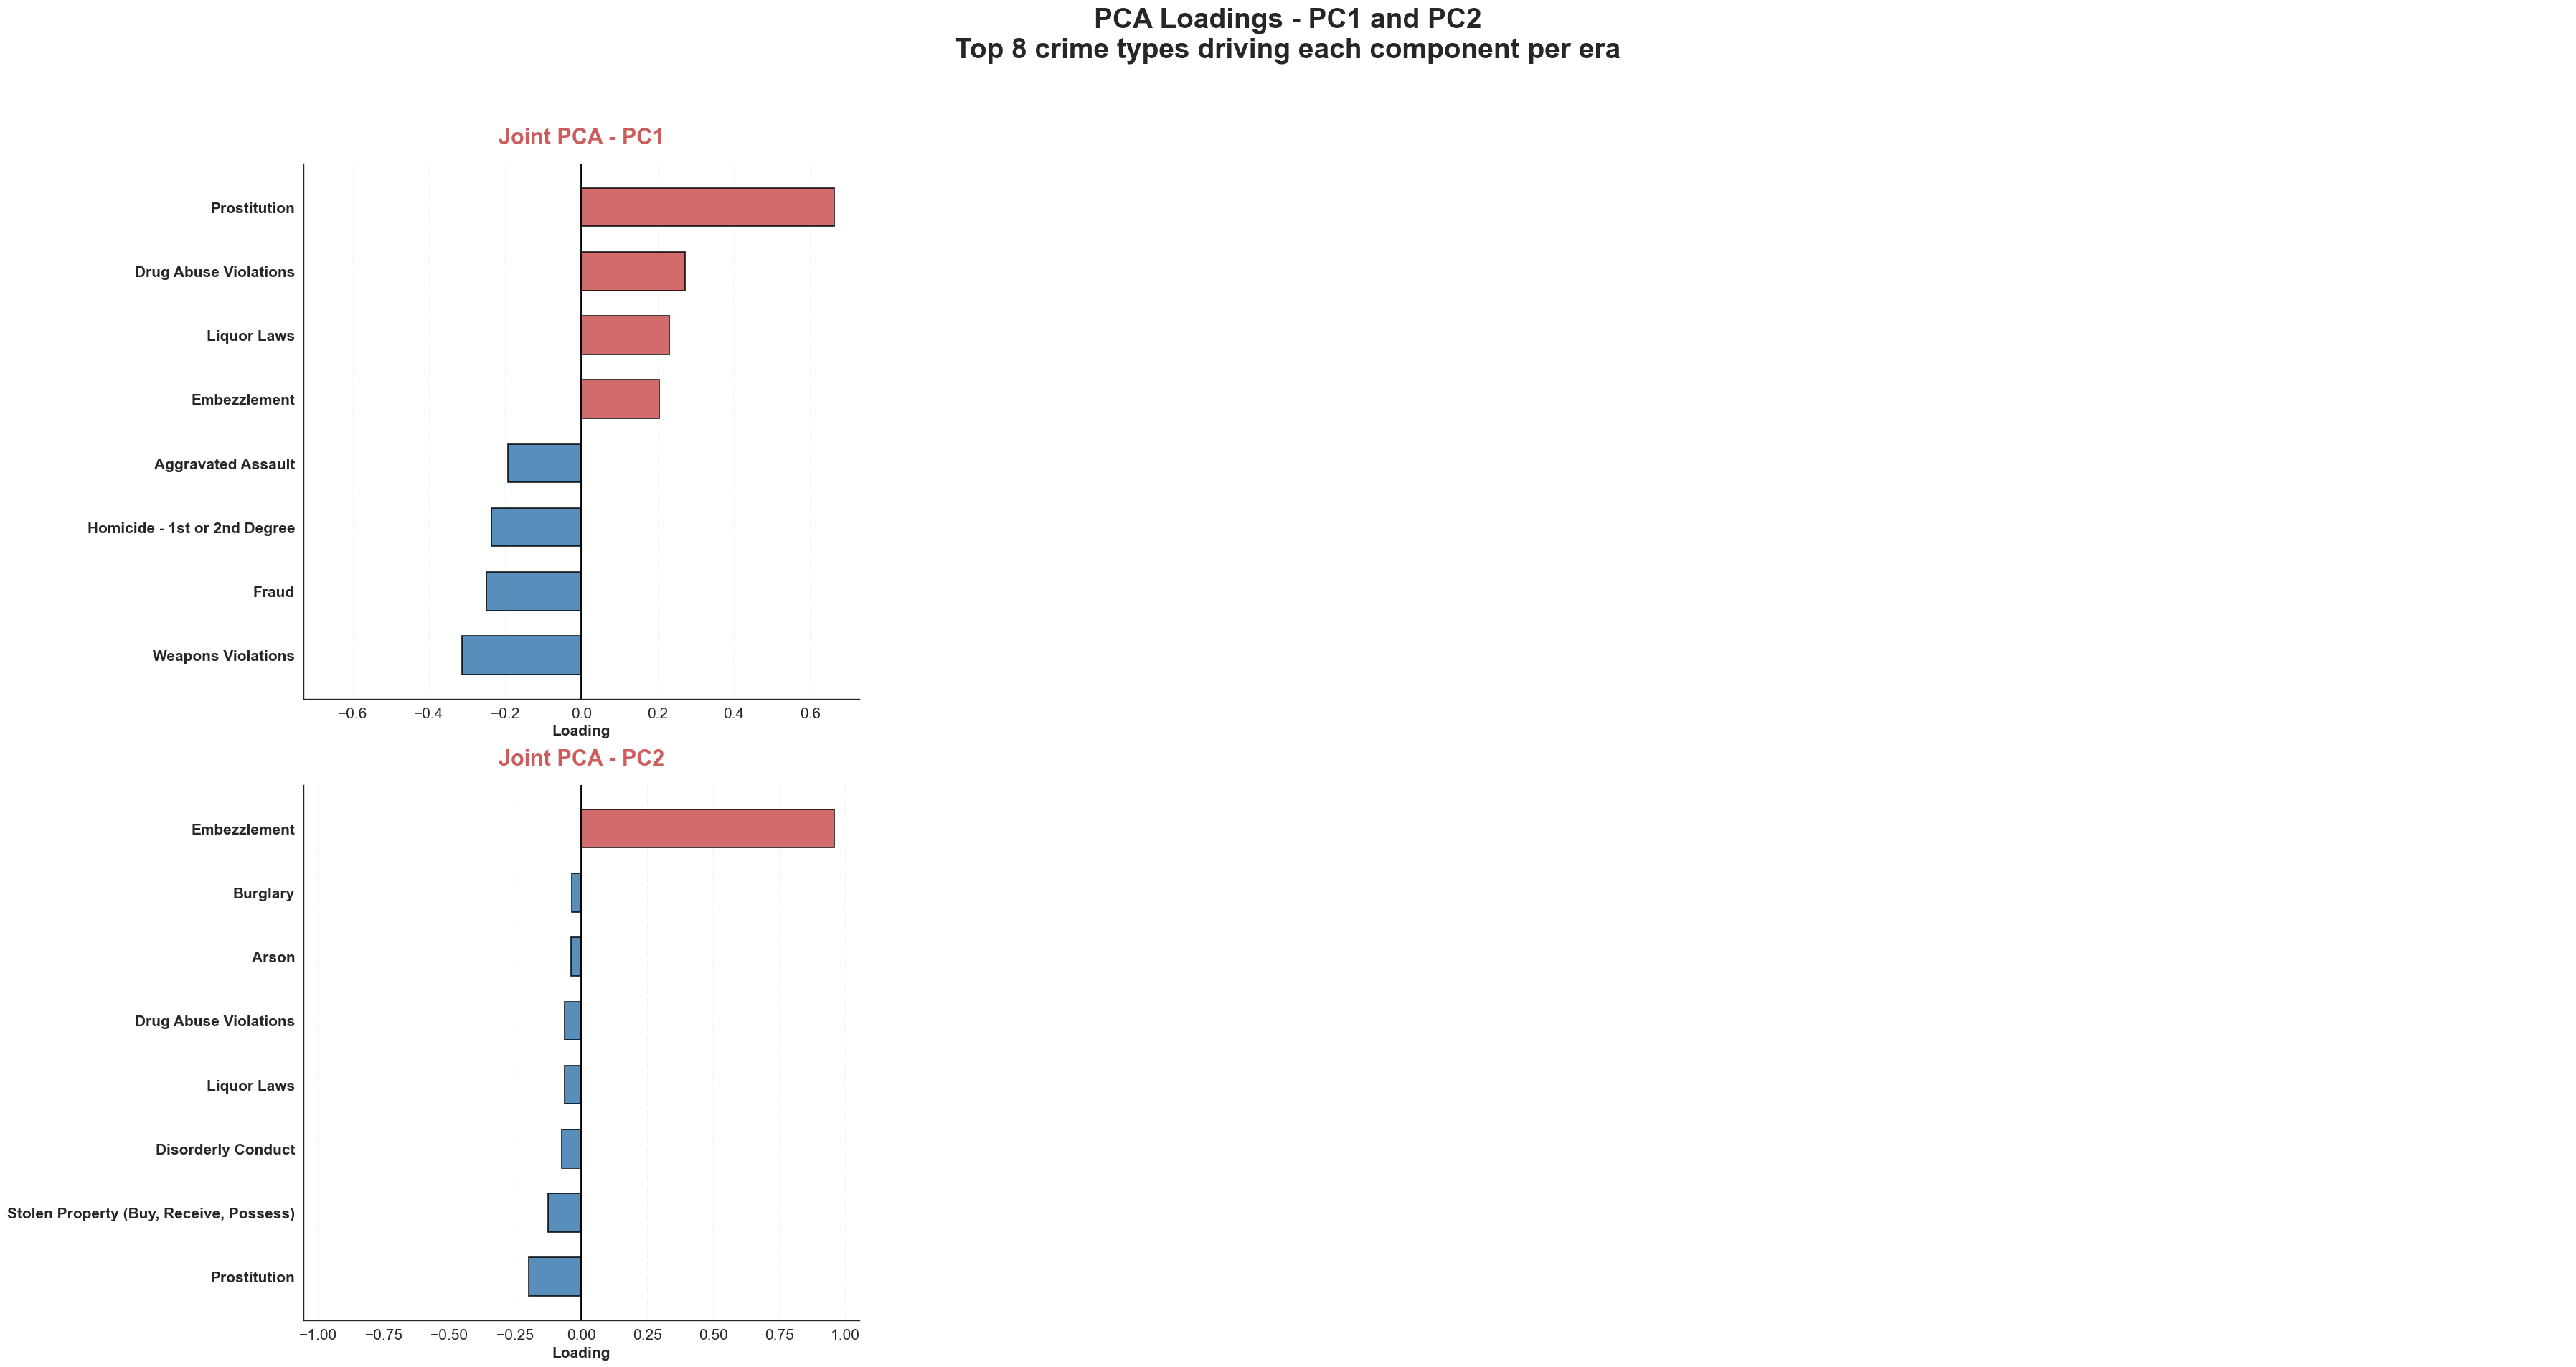

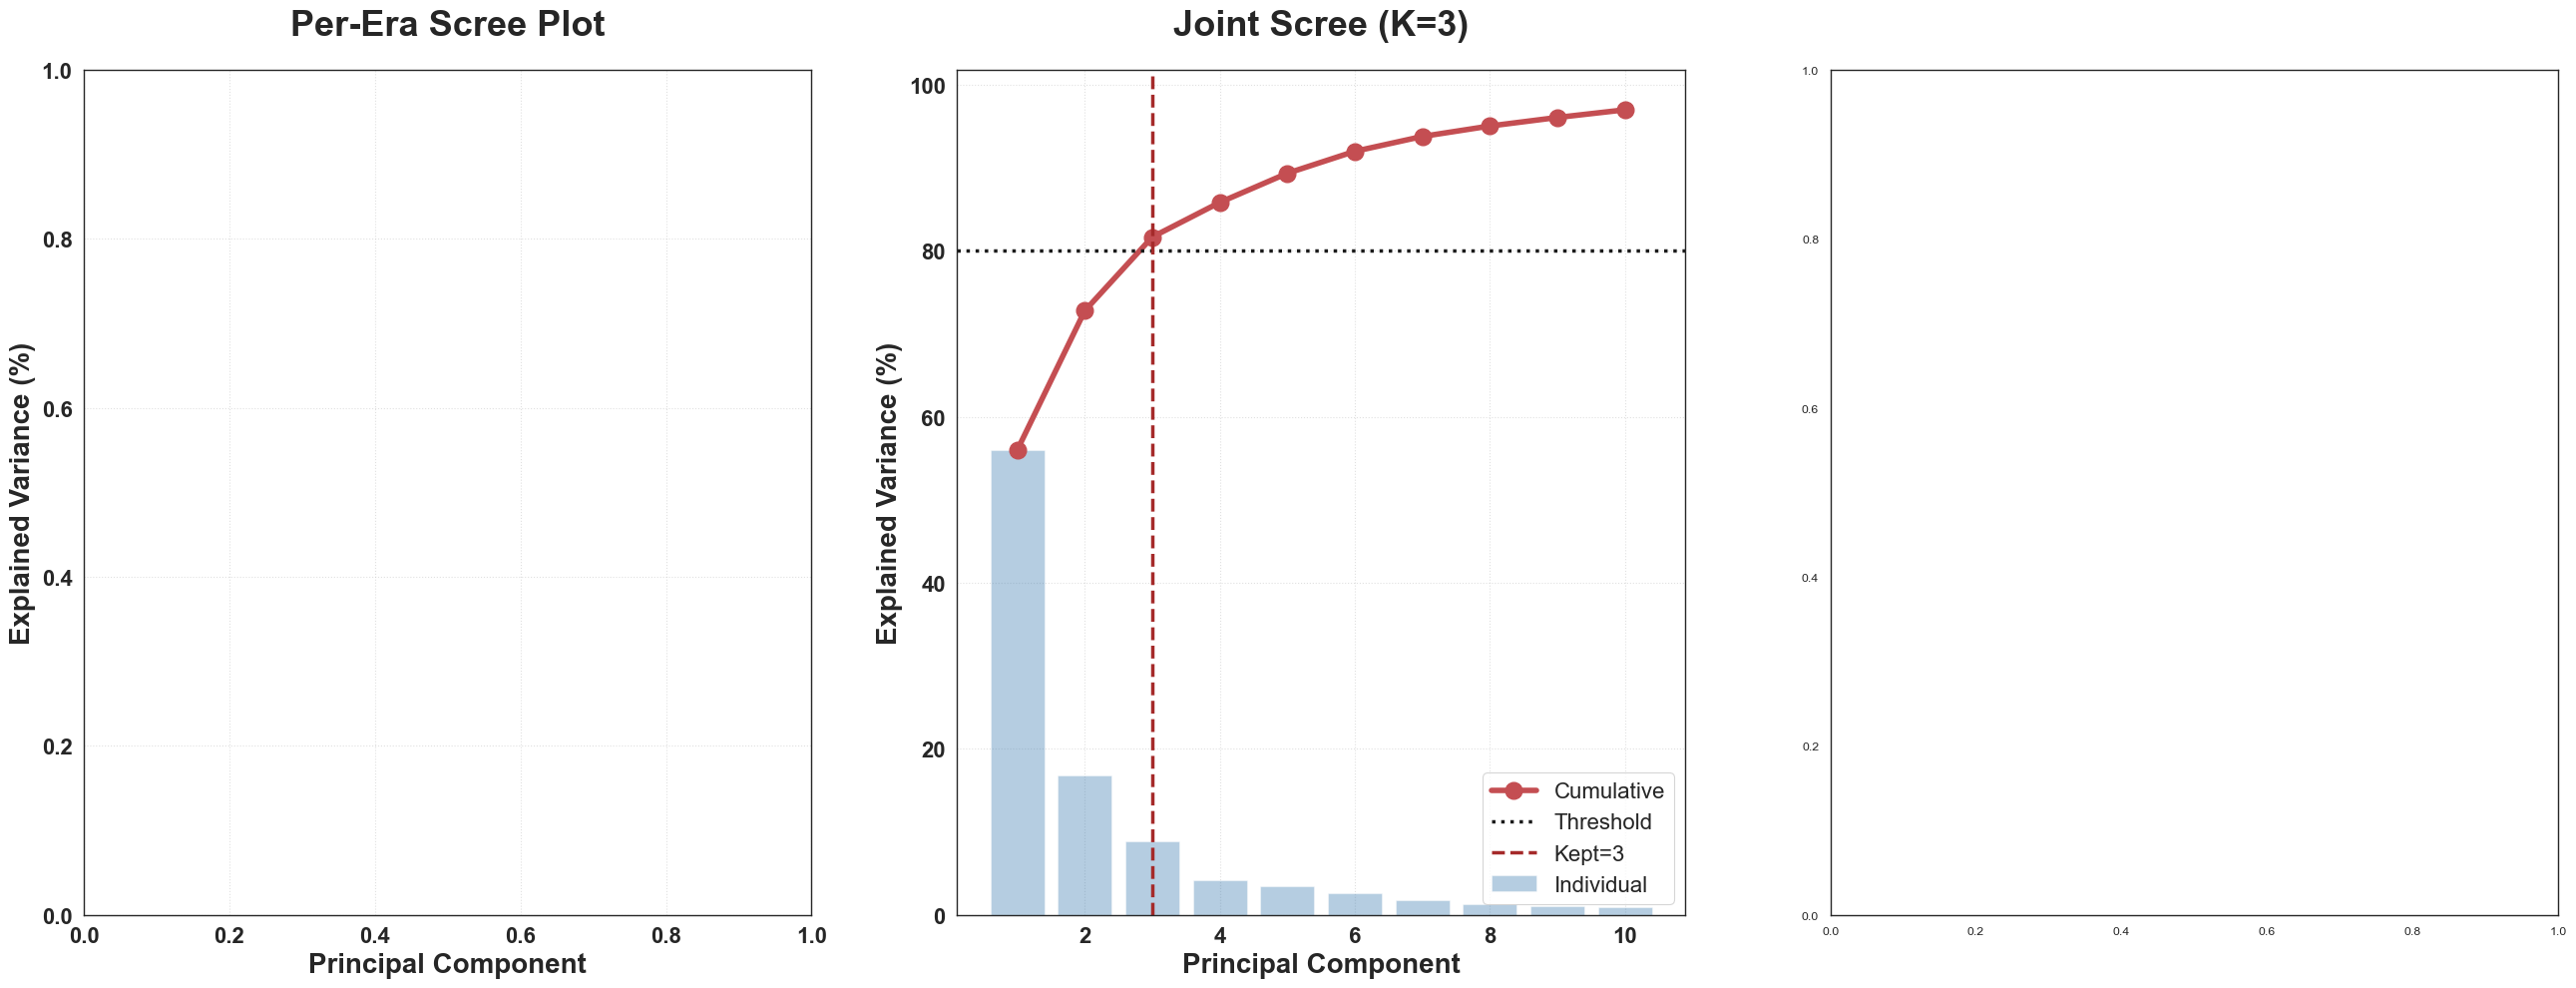

In [38]:
# Run PCA Analysis
pca_results = clr.run_pca_analysis(
    clr_era,
    chosen_clr,
    sparse_cats,
    seed               = _RANDOM_STATE,
    era_config         = cfg.era_config,
    variance_threshold = 0.80,
    show_plots         = True,
    save_plots         = True,
    image_path         = image_path
)

In [55]:
# Full scores and loadings per era
pca_results['Pre-COVID']['scores_full']
pca_results['Pre-COVID']['loadings_full']
pca_results['COVID']['scores_full']
pca_results['Post-COVID']['loadings_full']

# Sliced (retained components only)
pca_results['Pre-COVID']['scores']
pca_results['Pre-COVID']['loadings']

# Joint
pca_results['Joint']['scores']
pca_results['Joint']['loadings']
pca_results['Joint']['centroids']

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
era,,,,,,,,
Pre-COVID,0.149706,0.074515,-0.014283,0.014754,-0.031999,-0.055281,-0.024995,-0.112015
COVID,-0.223017,-0.113525,0.120801,0.098089,-0.100491,0.037725,-0.341057,0.100255
Post-COVID,-0.165601,-0.080915,-0.043915,-0.088361,0.124294,0.087926,0.254625,0.163877


In [53]:
covid_scores = pca_results['Post-COVID']['scores']

outliers = covid_scores[
    abs(covid_scores['PC1']) > 3.0
]

print(
    outliers[['PC1', 'PC2']]
    .sort_values('PC1', ascending=False)
)

                 PC1       PC2
year_month                    
2026-02-01 -4.021890  0.155107
2024-12-01 -4.159172  0.804276
2025-11-01 -4.234705  0.585021
2025-12-01 -4.253938 -2.208758
2025-04-01 -4.340518  0.340469


In [106]:
# Check all December months across all eras
scores = pca_results['joint_full_scores']      

# Add month column
scores = scores.copy()                           
scores['month'] = scores.index.month

# Compare winter vs other months on PC2
dec_pc2   = scores[scores['month'] == 12]['PC2'].mean()
nov_pc2   = scores[scores['month'] == 11]['PC2'].mean()
feb_pc2   = scores[scores['month'] ==  2]['PC2'].mean()
other_pc2 = scores[~scores['month'].isin([11,12,2])]['PC2'].mean()

print(f"December mean PC2  : {dec_pc2:+.3f}")
print(f"November mean PC2  : {nov_pc2:+.3f}")
print(f"February mean PC2  : {feb_pc2:+.3f}")
print(f"All other mean PC2 : {other_pc2:+.3f}")

December mean PC2  : -0.016
November mean PC2  : -0.358
February mean PC2  : -0.138
All other mean PC2 : +0.057


In [97]:
scores = pca_results['joint_full_scores'].copy()
pc2_mean = scores['PC2'].mean()
pc2_std  = scores['PC2'].std()

print(f"PC2 mean : {pc2_mean:+.3f}")
print(f"PC2 std  : {pc2_std:.3f}")

for val in [-3.35, -3.74, -3.62, -3.82]:
    z = (val - pc2_mean) / pc2_std
    print(f"  PC2={val:.2f}  z-score={z:.2f}")

PC2 mean : -0.000
PC2 std  : 1.058
  PC2=-3.35  z-score=-3.17
  PC2=-3.74  z-score=-3.54
  PC2=-3.62  z-score=-3.42
  PC2=-3.82  z-score=-3.61


### PCA Analysis

---

#### Scree Plot

Principal Component Analysis was performed on 23 dense CLR crime categories using singular value decomposition of the centered CLR data matrix, which is equivalent to covariance-based PCA without Ledoit-Wolf regularization. Three sparse categories, Gambling, Involuntary Manslaughter, and Prostitution, were excluded before fitting, yielding a joint matrix of shape (304, 23). The joint PCA scree plot retains three components at the 80% variance threshold, with PC1 explaining 46.9%, PC2 21.7%, and PC3 11.5%, for a cumulative variance of 80.1%. A clear elbow after PC3, where the explained variance drops from 11.5% to 4.2%, confirms that three components are the appropriate number.

The per-era scree plots reveal a structurally significant progression across the three periods. Pre-COVID requires four components to explain 81.0% of its variance, with PC1 at 45.1% and PC2 at 21.5%, with a gap of 23.6 percentage points, indicating a moderately distributed latent structure. COVID has the flattest scree of the three eras: PC1 at 42.7% and PC2 at 31.6%, a gap of only 11.1 percentage points, with three components explaining 84.7% of the variance. This near-equal split between the first two components indicates that COVID-era crime variance was distributed across multiple independent dimensions simultaneously and is consistent with the log-determinant expansion of +43.66 log units and the broad decoupling of crime types identified in the covariance structure analysis. Post-COVID has the most concentrated structure of the three eras, where PC1 alone explains 69.8%, with a gap of 59.7 percentage points over PC2 at 10.1%, and the three components explain 87.8%. This progression from a distributed four-factor pre-pandemic structure to a single-dominant-factor post-pandemic structure confirms that COVID did not diversify Chicago's latent crime composition; it simplified it, concentrating variance into one dominant dimension.

---

#### Joint PCA Scatter

The joint PCA scatter plot projects all 304 monthly CLR observations into the shared PC1-PC2 space, with months colored by administrative era and era centroids marked with stars. The three eras occupy quantitatively distinct regions confirmed by exact centroid coordinates. Pre-COVID months (n=230, blue) cluster tightly at the centroid (PC1=−0.6569, PC2=−0.0880), forming a compact cloud on the left side of the plot and reflecting the stable, predictable crime composition of the pre-pandemic period. The tight clustering is consistent with the low variance and small scree gap (23.6 pp) found in the per-era analysis. COVID months (n=34, red) scatter widely at centroid PC1=+2.3701, PC2=+0.3952, displaced 3.027 PC1 units to the right of Pre-COVID. Several COVID months extend to PC1 > 3.5, representing the most compositionally disrupted months of early 2020, which is consistent with the broad volatility spike and log-determinant expansion identified earlier. Post-COVID months (n=40, green) cluster at centroid PC1=+1.7626, PC2=+0.1699, positioned close to COVID and far from Pre-COVID.

The PC1 structural shift analysis quantifies the degree of permanent regime change. The total Pre->COVID shift along PC1 is 3.027 units. Post-COVID reverts only 0.608 units toward the pre-pandemic baseline, 20.1% reversion, while leaving 79.9% of the pandemic structural shift permanently encoded in the post-COVID crime composition. This is the strongest single visual confirmation of permanent structural regime change in the analysis, consistent with 19 of 23 confirmed categories showing significant net shifts in the bootstrap Pre->Post comparison and with the net log-determinant expansion of +23.79 log units. Notably, the PC3 centroid shows a monotonic increase across all three eras: Pre-COVID (−0.181), COVID (+0.359), Post-COVID (+0.735), with Post-COVID PC3 continuing to grow rather than reverting. This suggests a third latent dimension that continued to evolve into the post-COVID period and is not captured by the PC1 reversion narrative alone.

---

#### Post-COVID Outlier Sub-Cluster

Four post-COVID months, December 2024, November 2025, December 2025, and February 2026, form a visible sub-cluster at extreme negative PC2 values of −3.35 to −3.82, corresponding to z-scores of −3.27 to −3.73, and are more than three standard deviations below the PC2 mean of zero. Seasonal analysis ruled out a recurring seasonal pattern; the average PC2 across all December months is −0.036, confirming the sub-cluster is not driven by seasonality. CLR profile analysis of these four months reveals that Embezzlement deviates −3.99 CLR units below the post-COVID mean, by far the largest single-category deviation, where all other 22 crime types show near-zero deviations (range −0.04 to +0.53), consistent with zero-sum compositional rebalancing when one dominant category collapses. Stolen Property shows the largest compensating absorption (+0.53), consistent with its inverse compositional relationship with Embezzlement identified in the covariance analysis. These months represent the negative volatility tail of Embezzlement, which is the confirmed highest post-COVID variance category (std=1.6526) rather than an emerging structural trend or seasonal pattern.

---

#### PCA Loadings

**Joint PC1 - Violence versus Enforcement Axis.** Joint PC1 loadings confirm a violence-versus-enforcement contrast axis where positive loadings on Weapons Violations (+0.40), Fraud (+0.30), Homicide (+0.28), and Aggravated Assault (+0.25) oppose negative loadings on Embezzlement (−0.32), Drug Abuse Violations (−0.25), Liquor Laws (−0.18), and Stolen Property (−0.15). High PC1 scores correspond to months dominated by violent and fraud-related crime; low PC1 scores correspond to months dominated by enforcement-driven categories. This directly explains the era separation in the scatter plot of Pre-COVID months cluster in the enforcement region (PC1=−0.657) while COVID and Post-COVID months cluster in the violence region (PC1=+2.370 and +1.763), consistent with the CLR mean shift and bootstrap findings showing Weapons Violations (+1.48), Homicide (+1.10), and Aggravated Assault (+0.86) rising simultaneously as Drug Abuse Violations fell (−1.20) during COVID.

**Joint PC2 - Embezzlement Contrast Axis.** Joint PC2 loadings confirm the Embezzlement contrast axis predicted from the outlier analysis, in which Embezzlement loads at +0.85 with Stolen Property (−0.20), Drug Abuse (−0.12), and Liquor Laws (−0.15) opposing. High PC2 months are those where Embezzlement dominates the crime composition; low PC2 months, including the four extreme outliers at z=−3.27 to −3.73, are those where Embezzlement collapsed, and Stolen Property filled the compositional space.

**Per-Era PC1 - Structural Simplification.** Pre-COVID PC1 loads on multi-crime enforcement clusters such as Stolen Property (+0.45), Liquor Laws (+0.38), Embezzlement (+0.30), and Drug Abuse Violations (+0.27), with four crime types sharing the first component's explanatory power. This reflects the richer, more distributed pre-pandemic latent structure. In stark contrast, COVID PC1 is almost entirely monopolized by Embezzlement alone (loading=+0.95), and Post-COVID PC1 remains Embezzlement-dominated (loading=+0.90). This monopoly of the first principal component by a single volatile category in both pandemic eras confirms the Embezzlement volatility anomaly identified in the CLR standard deviation analysis; its variance is so large relative to all other categories that it alone defines the first latent dimension of Chicago's post-pandemic crime space.

**Per-Era PC2 - Property Crime Emergence.** Pre-COVID PC2 loads on a financial crime cluster such as Embezzlement (+0.55), Fraud (+0.25), and Criminal Sexual Assault (+0.22). COVID PC2 shifts to Stolen Property dominance (loading=+0.90), consistent with Stolen Property's volatility spike during COVID (Pre->COVID std Δ=−0.748). Post-COVID PC2 continues Stolen Property dominance (loading = +0.85), with secondary contributions from Embezzlement (+0.30), Disorderly Conduct (+0.20), and Drug Abuse Violations (+0.18), forming a broader property and disorder cluster that replaces the pre-pandemic financial crime cluster as the second latent dimension.

In [50]:
# t2_mds_results = run_hotelling_mds(
#     pca_data       = pca_results['pca_data'],
#     era_config     = era_config,
#     n_permutations = 10_000,
#     seed           = _RANDOM_STATE,
#     save_path      = image_path
# )

In [58]:
import importlib
importlib.reload(clr)

<module 'era_clr' from '/Users/sir/Desktop/Project/ChicagoCrime/Notebook/../Src/era_clr.py'>

In [48]:
# ============================================================
# HOTELLING T² + MDS ANALYSIS
# ============================================================
# New imports needed at top of era_clr.py
from sklearn.manifold      import MDS
from sklearn.covariance    import LedoitWolf
from scipy.spatial.distance import squareform
# ============================================================
# Step 1 - Hotelling T² with permutation
# Step 2 - MDS with Mahalanobis distance
# Step 3 - Orchestrator
# ============================================================


# ============================================================
# Step 1 - HOTELLING T²
# ============================================================
def _pooled_lw_covariance(X1, X2):
    """
    Compute the pooled Ledoit-Wolf regularized covariance
    from two era matrices.

    Σ_pool = [(n1-1)Σ_lw1 + (n2-1)Σ_lw2] / (n1+n2-2)

    Parameters
 -
    X1, X2 : np.ndarray  (T1, K) and (T2, K)

    Returns
  -
    Σ_pool : (K, K) np.ndarray
    α1, α2 : shrinkage intensities
    """
    n1, n2  = X1.shape[0], X2.shape[0]

    lw1     = LedoitWolf(assume_centered=False).fit(X1)
    lw2     = LedoitWolf(assume_centered=False).fit(X2)

    Σ_pool  = ((n1 - 1) * lw1.covariance_ +
                (n2 - 1) * lw2.covariance_) / (n1 + n2 - 2)

    return Σ_pool, lw1.shrinkage_, lw2.shrinkage_


def _hotelling_t2(X1, X2, Σ_pool):
    """
    Compute Hotelling T² statistic.

    T² = (n1*n2)/(n1+n2) * (μ1-μ2)ᵀ Σ_pool⁻¹ (μ1-μ2)

    Parameters
 -
    X1, X2  : np.ndarray  era matrices
    Σ_pool  : (K, K) pooled covariance

    Returns
  -
    T2 : float
    """
    n1, n2   = X1.shape[0], X2.shape[0]
    mu1, mu2 = X1.mean(axis=0), X2.mean(axis=0)
    diff     = mu1 - mu2

    # Use pseudo-inverse for numerical safety
    Σ_inv    = np.linalg.pinv(Σ_pool)
    T2       = (n1 * n2) / (n1 + n2) * diff @ Σ_inv @ diff

    return float(T2)


def run_hotelling_t2(pca_data, n_permutations=10_000,
                     seed=1776):
    """
    Hotelling T² test for all three era-pair comparisons
    using pooled LW covariance and permutation p-values.

    Comparisons:
      Pre-COVID vs COVID
      COVID     vs Post-COVID
      Pre-COVID vs Post-COVID

    Parameters
 -
    pca_data       : output of _prepare_pca_data
                     uses era_matrices (sparse already dropped)
    n_permutations : permutation iterations
    seed           : random seed

    Returns
  -
    dict:
        results : dict  comparison -> {
            T2_obs  : observed T² statistic
            p_perm  : permutation p-value
            reject  : bool  p < 0.05
            n1, n2  : sample sizes
            alpha1  : LW shrinkage era 1
            alpha2  : LW shrinkage era 2
        }
    """
    rng      = np.random.default_rng(seed)
    matrices = pca_data['era_matrices']

    comparisons = [
        ('Pre-COVID', 'COVID'),
        ('COVID',     'Post-COVID'),
        ('Pre-COVID', 'Post-COVID'),
    ]

    results = {}

    print()
    print("=" * 70)
    print("HOTELLING T² TEST - ERA CENTROID SEPARATION")
    print("=" * 70)
    print(f"  Method       : Pooled LW covariance + permutation")
    print(f"  Permutations : {n_permutations:,}  seed={seed}")
    print(f"  Dimensions   : K={pca_data['K']} dense crime types")
    print(f"  H₀           : μ_era1 = μ_era2 in CLR space")
    print(f"  H₁           : μ_era1 ≠ μ_era2")
    print()
    print(f"  {'Comparison':<30} {'T²':>10} {'p (perm)':>10} "
          f"{'Result':>20} {'α1':>8} {'α2':>8}")
    print(f"  {'-'*70}")

    for era1, era2 in comparisons:
        X1 = matrices[era1].values
        X2 = matrices[era2].values
        n1, n2 = X1.shape[0], X2.shape[0]

        # Pooled LW covariance
        Σ_pool, α1, α2 = _pooled_lw_covariance(X1, X2)

        # Observed T²
        T2_obs = _hotelling_t2(X1, X2, Σ_pool)

        # Permutation distribution
        all_data = np.vstack([X1, X2])
        N        = n1 + n2
        T2_perm  = np.empty(n_permutations)

        for i in range(n_permutations):
            idx      = rng.permutation(N)
            X1_perm  = all_data[idx[:n1]]
            X2_perm  = all_data[idx[n1:]]
            Σ_p, _, _ = _pooled_lw_covariance(X1_perm,
                                                X2_perm)
            T2_perm[i] = _hotelling_t2(X1_perm,
                                        X2_perm, Σ_p)

        p_perm = float(np.mean(T2_perm >= T2_obs))
        reject = p_perm < 0.05
        label  = '✅ reject H0' if reject else '❌ fail to reject'
        key    = f"{era1} vs {era2}"

        results[key] = {
            'T2_obs' : T2_obs,
            'T2_perm': T2_perm,
            'p_perm' : p_perm,
            'reject' : reject,
            'n1'     : n1,
            'n2'     : n2,
            'alpha1' : α1,
            'alpha2' : α2,
        }

        print(f"  {key:<30} {T2_obs:>10.2f} {p_perm:>10.4f} "
              f"{label:>20} {α1:>8.4f} {α2:>8.4f}")

    print()
    print(f"  α1, α2 = LW shrinkage per era in each comparison")
    print(f"  T²     = (n1*n2)/(n1+n2) * Δμᵀ Σ_pool⁻¹ Δμ")
    print(f"  p      = permutation-based, {n_permutations:,} iterations")

    return {'results': results}


def plot_hotelling_permutation(t2_results, save_path=None):
    """
    Plot permutation distributions for all three T² tests.

    Parameters
 -
    t2_results : output of run_hotelling_t2
    save_path  : directory for saving

    Returns
  -
    dict: empty (side-effect only)
    """
    comparisons = list(t2_results['results'].keys())
    fig, axes   = plt.subplots(1, 3, figsize=(18, 5))

    for ax, key in zip(axes, comparisons):
        res     = t2_results['results'][key]
        T2_obs  = res['T2_obs']
        T2_perm = res['T2_perm']
        p       = res['p_perm']

        ax.hist(T2_perm, bins=60,
                color='steelblue', alpha=0.7,
                edgecolor='white', linewidth=0.3)
        ax.axvline(T2_obs, color='red',
                   linewidth=2.5, linestyle='--',
                   label=f'Observed T²={T2_obs:.1f}')

        ax.set_title(
            f"{key} | p={p:.4f} | {'Reject $H_0$' if res['reject'] else 'Fail to reject $H_0$'}",
            fontsize=11,
            fontweight='bold'
        )

        ax.set_xlabel(r"$T^2$ statistic", fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        "Hotelling $T^2$ Permutation Distributions\n"
        "Red = observed statistic  |  "
        "Pooled LW covariance  |  10,000 permutations",
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(f"{save_path}hotelling_permutation.png",
                    dpi=300, bbox_inches='tight')
    plt.show()

    return {}


# ============================================================
# Step 2 - MDS WITH MAHALANOBIS DISTANCE
# ============================================================
def _mahalanobis_distance_matrix(X, Σ_pool_inv):
    """
    Compute pairwise Mahalanobis distances for all
    rows of X using a single pooled inverse covariance.

    d(i,j) = √[(xᵢ-xⱼ)ᵀ Σ⁻¹ (xᵢ-xⱼ)]

    Parameters
 -
    X          : (N, K) np.ndarray
    Σ_pool_inv : (K, K) inverse pooled covariance

    Returns
  -
    D : (N, N) symmetric distance matrix
    """
    N   = X.shape[0]
    D   = np.zeros((N, N))
    for i in range(N):
        diff      = X[i] - X          # (N, K)
        # d²(i,j) = diff @ Σ⁻¹ @ diff.T diagonal
        d2        = np.einsum('nk,kl,nl->n',
                               diff, Σ_pool_inv, diff)
        D[i]      = np.sqrt(np.maximum(d2, 0))
    return D


def run_mds(pca_data, era_config, n_components=2,
            seed=1776, save_path=None):
    """
    Multidimensional Scaling using Mahalanobis distance.

    Uses pooled LW covariance across all three eras
    as the single consistent metric for the full
    304-month distance matrix.

    Parameters
 -
    pca_data    : output of _prepare_pca_data
    era_config  : dict  era -> (start, end, color)
    n_components: MDS output dimensions (default 2)
    seed        : random seed
    save_path   : directory for saving

    Returns
  -
    dict:
        embedding   : (304, 2) MDS coordinates DataFrame
        stress      : MDS stress value
        centroids   : (3, 2) era centroid coordinates
        D           : (304, 304) Mahalanobis distance matrix
    """
    X          = pca_data['joint_matrix'].values
    N, K       = X.shape
    era_labels = pca_data['era_labels']
    era_colors = pca_data['era_colors']

    # -- Pooled LW covariance across all three eras--------
    lw         = LedoitWolf(assume_centered=False).fit(X)
    Σ_pool_inv = np.linalg.pinv(lw.covariance_)
    α_pooled   = lw.shrinkage_

    print()
    print("=" * 70)
    print("MDS - MAHALANOBIS DISTANCE")
    print("=" * 70)
    print(f"  Distance metric  : Mahalanobis")
    print(f"  Covariance       : Pooled LW (all 304 months)")
    print(f"  LW shrinkage α   : {α_pooled:.4f}")
    print(f"  MDS dimensions   : {n_components}")
    print(f"  Matrix size      : ({N} × {N})")
    print(f"  Computing pairwise distances...")

    # -- Pairwise Mahalanobis distance matrix--------------
    D = _mahalanobis_distance_matrix(X, Σ_pool_inv)

    print(f"  Fitting MDS...")

    # Initialize MDS on distance matrix (26 × 26)
    # Note: dissimilarity is the correct param for precomputed matrices
    mds = MDS(
        n_components=n_components,
        metric='precomputed',   # use precomputed distances
        n_init=1, 
        init = 'classical_mds',
        max_iter=1000,
        normalized_stress=True,
        random_state=_RANDOM_STATE
    )
    
    embedding_arr = mds.fit_transform(D)
    stress        = mds.stress_

    embedding = pd.DataFrame(
        embedding_arr,
        index   = pca_data['joint_matrix'].index,
        columns = [f"MDS{i+1}" for i in range(n_components)]
    )
    embedding['era']   = era_labels
    embedding['color'] = era_colors

    # -- Era centroids-
    centroids = {}
    for era in era_config:
        mask           = embedding['era'] == era
        centroids[era] = {
            'MDS1' : embedding.loc[mask, 'MDS1'].mean(),
            'MDS2' : embedding.loc[mask, 'MDS2'].mean(),
            'color': era_config[era][2],
            'n'    : mask.sum(),
        }

    print(f"  Stress           : {stress:.4f}  "
          f"{'✅ good' if stress < 0.1 else '⚠️ acceptable' if stress < 0.2 else '❌ poor'}")
    print()
    print(f"  Era centroids in MDS space:")
    for era, c in centroids.items():
        print(f"    {era:<15}: MDS1={c['MDS1']:+.3f}  "
              f"MDS2={c['MDS2']:+.3f}  n={c['n']}")

    # -- Plot----------
    fig, ax = plt.subplots(figsize=(12, 8))

    # Individual months - transparent
    for era in era_config:
        color  = era_config[era][2]
        mask   = embedding['era'] == era
        subset = embedding[mask]
        ax.scatter(
            subset['MDS1'], subset['MDS2'],
            c=color, alpha=0.3, s=25,       
            edgecolors='none',
            label=f"{era} (n={mask.sum()})"
        )

    # Era centroids - prominent
    for era, c in centroids.items():
        ax.scatter(
            c['MDS1'], c['MDS2'],
            c=c['color'], s=300,
            marker='*', edgecolors='black',
            linewidths=1.5, zorder=10
        )
        ax.annotate(
            era, (c['MDS1'], c['MDS2']),
            textcoords='offset points',
            xytext=(10, 5),
            fontsize=11, fontweight='bold',
            color=c['color']
        )

    # Centroid triangle
    era_keys = list(era_config.keys())
    for i in range(len(era_keys)):
        e1 = era_keys[i]
        e2 = era_keys[(i + 1) % len(era_keys)]
        ax.plot(
            [centroids[e1]['MDS1'], centroids[e2]['MDS1']],
            [centroids[e1]['MDS2'], centroids[e2]['MDS2']],
            'k--', linewidth=1.0, alpha=0.4
        )

    ax.set_xlabel('MDS Dimension 1', fontsize=12)
    ax.set_ylabel('MDS Dimension 2', fontsize=12)
    ax.set_title(
        'MDS - Mahalanobis Distance in CLR Space\n'
        f'Pooled LW covariance  |  '
        f'Stress={stress:.4f}  |  ★ = era centroid',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=11)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.4)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.4)
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(f"{save_path}mds_mahalanobis.png",
                    dpi=300, bbox_inches='tight')
    plt.show()

    return {
        'embedding' : embedding,
        'stress'    : stress,
        'centroids' : centroids,
        'D'         : D,
        'alpha_pool': α_pooled,
    }


# ============================================================
# Step 3 - ORCHESTRATOR
# ============================================================
def run_hotelling_mds(pca_data, era_config,
                      n_permutations=10_000,
                      seed=1776,
                      save_path=None):
    """
    Hotelling T² + MDS analysis pipeline.

    Steps
   --
    1. Hotelling T² - formal test of era centroid separation
       for all three era-pair comparisons using pooled
       LW covariance and permutation p-values
    2. Permutation distribution plots
    3. MDS - Mahalanobis distance visualization
       individual months (α=0.3) + era centroids (★)

    Parameters
 -
    pca_data       : output of _prepare_pca_data
    era_config     : dict  era -> (start, end, color)
    n_permutations : permutation iterations (default 10,000)
    seed           : random seed (default 1776)
    save_path      : directory for saving plots

    Returns
  -
    dict:
        t2  : Hotelling T² results
        mds : MDS results
    """
    print("\n" + "=" * 70)
    print("HOTELLING T² + MDS ANALYSIS")
    print("=" * 70)

    # Step 1 - Hotelling T²
    t2 = run_hotelling_t2(
        pca_data,
        n_permutations = n_permutations,
        seed           = seed,
    )

    # Step 2 - Permutation plots
    print("\nPlotting permutation distributions...")
    plot_hotelling_permutation(t2, save_path=save_path)

    # Step 3 - MDS
    print("Fitting MDS with Mahalanobis distance...")
    mds = run_mds(
        pca_data,
        era_config   = era_config,
        n_components = 2,
        seed         = seed,
        save_path    = save_path,
    )

    print("\n" + "=" * 70)
    print("HOTELLING T² + MDS COMPLETE")
    print("=" * 70)

    return {
        't2' : t2,
        'mds': mds,
    }